## 20251003 Now we can try removing the "abnormal" NGC4383
The reason is that it almost occupies the entire independent parameter space in rMZR. 
So if we want to study the SFR dependence in rMZR, it will be biased by this single galaxy. 
Therefore, we can try removing it and see how the results change.

  IC3392: 14884 HII pixels, 19776 SF pixels
  NGC4064: 6820 HII pixels, 15383 SF pixels
  NGC4064: 6820 HII pixels, 15383 SF pixels
  NGC4192: 145934 HII pixels, 275015 SF pixels
  NGC4192: 145934 HII pixels, 275015 SF pixels
  NGC4293: 3854 HII pixels, 8590 SF pixels
  NGC4293: 3854 HII pixels, 8590 SF pixels
  NGC4298: 156350 HII pixels, 181696 SF pixels
  NGC4298: 156350 HII pixels, 181696 SF pixels
  NGC4330: 42566 HII pixels, 43709 SF pixels
  NGC4383: excluded from combined spaxel collection (color retained)
  NGC4330: 42566 HII pixels, 43709 SF pixels
  NGC4383: excluded from combined spaxel collection (color retained)
  NGC4396: 81728 HII pixels, 81734 SF pixels
  NGC4419: 6886 HII pixels, 22002 SF pixels
  NGC4396: 81728 HII pixels, 81734 SF pixels
  NGC4419: 6886 HII pixels, 22002 SF pixels
  NGC4457: 6000 HII pixels, 24136 SF pixels
  NGC4457: 6000 HII pixels, 24136 SF pixels
  NGC4501: 260854 HII pixels, 419043 SF pixels
  NGC4501: 260854 HII pixels, 419043 SF pixels
  NGC4

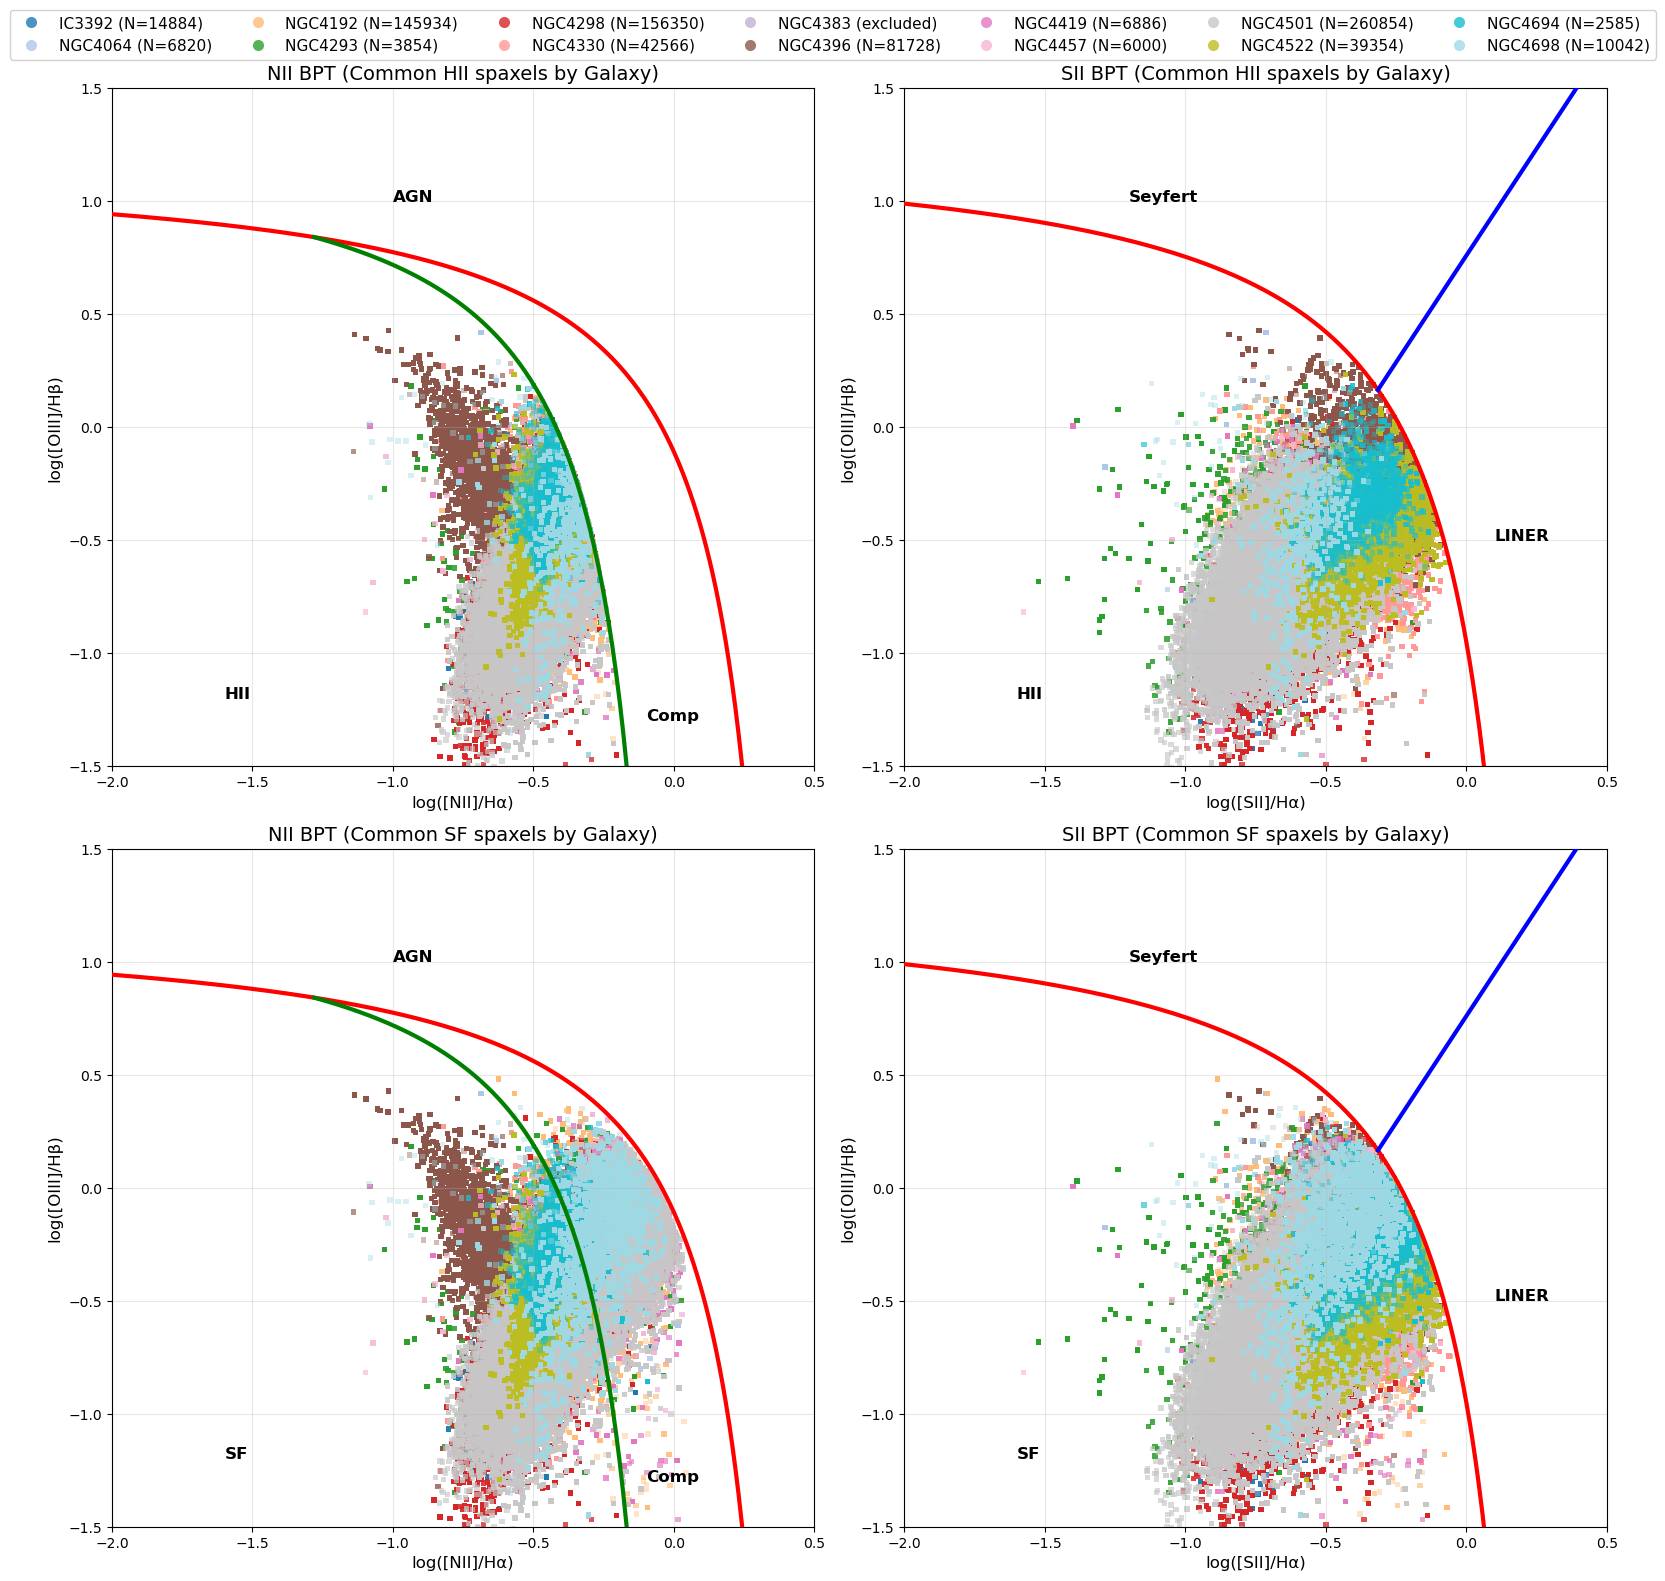


=== Combined BPT Diagram Summary ===

HII Regions:
  N2 BPT - Total HII: 777857 (100.0%)
  S2 BPT - Total HII: 777857 (100.0%)

SF Regions:
  N2 BPT - Total SF: 1169800 (100.0%)
  S2 BPT - Total SF: 1169800 (100.0%)

Galaxy breakdown for HII spaxels:
  IC3392: N2_HII=14884, S2_HII=14884
  NGC4064: N2_HII=6820, S2_HII=6820
  NGC4192: N2_HII=145934, S2_HII=145934
  NGC4293: N2_HII=3854, S2_HII=3854
  NGC4298: N2_HII=156350, S2_HII=156350
  NGC4330: N2_HII=42566, S2_HII=42566
  NGC4383: excluded (color retained)
  NGC4396: N2_HII=81728, S2_HII=81728
  NGC4419: N2_HII=6886, S2_HII=6886
  NGC4457: N2_HII=6000, S2_HII=6000
  NGC4501: N2_HII=260854, S2_HII=260854
  NGC4522: N2_HII=39354, S2_HII=39354
  NGC4694: N2_HII=2585, S2_HII=2585
  NGC4698: N2_HII=10042, S2_HII=10042

Galaxy breakdown for SF spaxels:
  IC3392: N2_SF=19776, S2_SF=19776
  NGC4064: N2_SF=15383, S2_SF=15383
  NGC4192: N2_SF=275015, S2_SF=275015
  NGC4293: N2_SF=8590, S2_SF=8590
  NGC4298: N2_SF=181696, S2_SF=181696
  NGC43

In [1]:
# ------------------------------------------------------------------
# Combined Analysis: NII and SII BPT Diagrams - Color-coded by Galaxy
# Collect all spaxels from all galaxies
# Uses common spaxels across all 4 metallicity calibrations
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
from astropy.io import fits

# BPT reference line functions
def kewley01_N2(x):   # max-starburst
    return 0.61/(x-0.47) + 1.19

def kauff03_N2(x):    # empirical SF upper envelope
    return 0.61/(x-0.05) + 1.30

def kewley01_S2(x):
    return 0.72/(x-0.32) + 1.30

def kewley06_Sy_LIN(x):   # Seyfert/LINER division
    return 1.89*x + 0.76

# Create x arrays for the theoretical lines
x_kewley_N2 = np.linspace(-2.0, 0.3, 200)
x_kauff_N2 = np.linspace((286-np.sqrt(2871561))/1100, 0.0, 200)
x_kewley_S2 = np.linspace(-2.0, 0.3, 200)
x_kewley06_S2 = np.linspace((159-np.sqrt(105081))/525, 0.5, 200)

# Get all galaxies from binning files
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

# Create galaxy color mapping (consistent for both HII and SF regions)
galaxy_colors = plt.cm.tab20(np.linspace(0, 1, len(galaxies)))
galaxy_color_dict = dict(zip(galaxies, galaxy_colors))

# Define galaxies to exclude from plotting while retaining color slots
excluded_galaxies = {'NGC4383'}

# Collect all spaxels from all galaxies - HII (with galaxy indices)
all_logN2_hii = []
all_logO3_hii = []
all_logS2_hii = []
all_galaxy_indices_hii = []

# Collect all spaxels from all galaxies - SF (with galaxy indices)
all_logN2_sf = []
all_logO3_sf = []
all_logS2_sf = []
all_galaxy_indices_sf = []

print("Collecting data from all galaxies...")
for gal_idx, gal in enumerate(galaxies):
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')
    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')

    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from combined spaxel collection (color retained)")
        continue

    if gas_file.exists() and bin_file.exists():
        # Load maps for this galaxy
        with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
            logSigmaM = h['LOGMASS_SURFACE_DENSITY'].data
        with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
            # HII
            logSigmaSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
            oh_d16_HII = h['O_H_D16_HII'].data
            oh_pg16_HII = h['O_H_PG16_HII'].data
            oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
            oh_o3n2_c20_HII = h['O_H_O3N2_C20_HII'].data
            
            # SF
            logSigmaSFR_SF = h['LOGSFR_SURFACE_DENSITY_SF'].data
            oh_d16_SF = h['O_H_D16_SF'].data
            oh_pg16_SF = h['O_H_PG16_SF'].data
            oh_o3n2_m13_SF = h['O_H_O3N2_M13_SF'].data
            oh_o3n2_c20_SF = h['O_H_O3N2_C20_SF'].data
            
            # Load corrected emission line fluxes
            HB4861_FLUX_corr = h['HB4861_FLUX_corr'].data
            HA6562_FLUX_corr = h['HA6562_FLUX_corr'].data
            OIII5006_FLUX_corr = h['OIII5006_FLUX_corr'].data
            NII6583_FLUX_corr = h['NII6583_FLUX_corr'].data
            SII6716_FLUX_corr = h['SII6716_FLUX_corr'].data
            SII6730_FLUX_corr = h['SII6730_FLUX_corr'].data
        
        # Find common spaxels for HII
        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                       np.isfinite(oh_d16_HII) & np.isfinite(oh_pg16_HII) & 
                       np.isfinite(oh_o3n2_m13_HII) & np.isfinite(oh_o3n2_c20_HII) &
                       np.isfinite(HB4861_FLUX_corr) & np.isfinite(HA6562_FLUX_corr) &
                       np.isfinite(OIII5006_FLUX_corr) & np.isfinite(NII6583_FLUX_corr) &
                       np.isfinite(SII6716_FLUX_corr) & np.isfinite(SII6730_FLUX_corr))
        
        # Find common spaxels for SF
        common_mask_SF = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_SF) & 
                       np.isfinite(oh_d16_SF) & np.isfinite(oh_pg16_SF) & 
                       np.isfinite(oh_o3n2_m13_SF) & np.isfinite(oh_o3n2_c20_SF) &
                       np.isfinite(HB4861_FLUX_corr) & np.isfinite(HA6562_FLUX_corr) &
                       np.isfinite(OIII5006_FLUX_corr) & np.isfinite(NII6583_FLUX_corr) &
                       np.isfinite(SII6716_FLUX_corr) & np.isfinite(SII6730_FLUX_corr))
        
        n_pixels_HII = np.sum(common_mask_HII)
        n_pixels_SF = np.sum(common_mask_SF)
        
        print(f"  {gal}: {n_pixels_HII} HII pixels, {n_pixels_SF} SF pixels")
        
        # Apply common_mask to get valid spaxels - HII
        HB_common_HII = HB4861_FLUX_corr[common_mask_HII]
        HA_common_HII = HA6562_FLUX_corr[common_mask_HII]
        OIII_common_HII = OIII5006_FLUX_corr[common_mask_HII]
        NII_common_HII = NII6583_FLUX_corr[common_mask_HII]
        SII6716_common_HII = SII6716_FLUX_corr[common_mask_HII]
        SII6730_common_HII = SII6730_FLUX_corr[common_mask_HII]
        
        # Apply common_mask to get valid spaxels - SF
        HB_common_SF = HB4861_FLUX_corr[common_mask_SF]
        HA_common_SF = HA6562_FLUX_corr[common_mask_SF]
        OIII_common_SF = OIII5006_FLUX_corr[common_mask_SF]
        NII_common_SF = NII6583_FLUX_corr[common_mask_SF]
        SII6716_common_SF = SII6716_FLUX_corr[common_mask_SF]
        SII6730_common_SF = SII6730_FLUX_corr[common_mask_SF]
        
        # Calculate line ratios - HII
        logN2_hii = np.log10(NII_common_HII / HA_common_HII)
        logO3_hii = np.log10(OIII_common_HII / HB_common_HII)
        logS2_hii = np.log10((SII6716_common_HII + SII6730_common_HII) / HA_common_HII)
        
        # Calculate line ratios - SF
        logN2_sf = np.log10(NII_common_SF / HA_common_SF)
        logO3_sf = np.log10(OIII_common_SF / HB_common_SF)
        logS2_sf = np.log10((SII6716_common_SF + SII6730_common_SF) / HA_common_SF)
        
        # Append to combined arrays - HII
        all_logN2_hii.extend(logN2_hii.flatten())
        all_logO3_hii.extend(logO3_hii.flatten())
        all_logS2_hii.extend(logS2_hii.flatten())
        all_galaxy_indices_hii.extend([gal_idx] * len(logN2_hii.flatten()))
        
        # Append to combined arrays - SF
        all_logN2_sf.extend(logN2_sf.flatten())
        all_logO3_sf.extend(logO3_sf.flatten())
        all_logS2_sf.extend(logS2_sf.flatten())
        all_galaxy_indices_sf.extend([gal_idx] * len(logN2_sf.flatten()))
    else:
        print(f"  {gal}: Data files not found")

# Convert to numpy arrays - HII
all_logN2_hii = np.array(all_logN2_hii)
all_logO3_hii = np.array(all_logO3_hii)
all_logS2_hii = np.array(all_logS2_hii)
all_galaxy_indices_hii = np.array(all_galaxy_indices_hii)

# Convert to numpy arrays - SF
all_logN2_sf = np.array(all_logN2_sf)
all_logO3_sf = np.array(all_logO3_sf)
all_logS2_sf = np.array(all_logS2_sf)
all_galaxy_indices_sf = np.array(all_galaxy_indices_sf)

print(f"\nTotal combined HII pixels: {len(all_logN2_hii)}")
print(f"Total combined SF pixels: {len(all_logN2_sf)}")

# Apply BPT classifications - HII
mask_N2_HII = all_logO3_hii <= kauff03_N2(all_logN2_hii)
mask_N2_Comp = (all_logO3_hii > kauff03_N2(all_logN2_hii)) & (all_logO3_hii <= kewley01_N2(all_logN2_hii))
mask_N2_AGN = all_logO3_hii > kewley01_N2(all_logN2_hii)

mask_S2_HII = all_logO3_hii <= kewley01_S2(all_logS2_hii)
mask_S2_above_kewley = all_logO3_hii > kewley01_S2(all_logS2_hii)
mask_S2_LINER = mask_S2_above_kewley & (all_logO3_hii <= kewley06_Sy_LIN(all_logS2_hii))
mask_S2_Seyfert = mask_S2_above_kewley & (all_logO3_hii > kewley06_Sy_LIN(all_logS2_hii))

mask_HII_N2 = mask_N2_HII | mask_N2_Comp
mask_HII_S2 = mask_S2_HII

# Apply BPT classifications - SF
mask_N2_HII_sf = all_logO3_sf <= kauff03_N2(all_logN2_sf)
mask_N2_Comp_sf = (all_logO3_sf > kauff03_N2(all_logN2_sf)) & (all_logO3_sf <= kewley01_N2(all_logN2_sf))
mask_N2_AGN_sf = all_logO3_sf > kewley01_N2(all_logN2_sf)

mask_S2_HII_sf = all_logO3_sf <= kewley01_S2(all_logS2_sf)
mask_S2_above_kewley_sf = all_logO3_sf > kewley01_S2(all_logS2_sf)
mask_S2_LINER_sf = mask_S2_above_kewley_sf & (all_logO3_sf <= kewley06_Sy_LIN(all_logS2_sf))
mask_S2_Seyfert_sf = mask_S2_above_kewley_sf & (all_logO3_sf > kewley06_Sy_LIN(all_logS2_sf))

mask_HII_N2_sf = mask_N2_HII_sf | mask_N2_Comp_sf
mask_HII_S2_sf = mask_S2_HII_sf

# Create BPT diagrams with 2 rows
fig, axes = plt.subplots(2, 2, figsize=(16, 16))

# ===== TOP ROW: HII REGIONS =====

# NII BPT Diagram - HII
ax = axes[0, 0]

for gal_idx, gal in enumerate(galaxies):
    gal_mask = (all_galaxy_indices_hii == gal_idx) & mask_HII_N2
    if np.sum(gal_mask) > 0:
        ax.scatter(all_logN2_hii[gal_mask], all_logO3_hii[gal_mask], 
                   color=galaxy_colors[gal_idx], marker=',', s=15, alpha=0.4, 
                   edgecolors='none', rasterized=True)

ax.plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'r-', lw=3, label='Kewley+01', zorder=10)
ax.plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'g-', lw=3, label='Kauffmann+03', zorder=10)

hii_count_N2 = np.sum(mask_HII_N2)
total_common_hii = len(all_logN2_hii)
hii_percent_N2 = hii_count_N2 / total_common_hii * 100 if total_common_hii > 0 else 0

ax.set_xlabel('log([NII]/Hα)', fontsize=12)
ax.set_ylabel('log([OIII]/Hβ)', fontsize=12)
ax.set_xlim(-2.0, 0.5)
ax.set_ylim(-1.5, 1.5)
ax.set_title(f'NII BPT (Common HII spaxels by Galaxy)', fontsize=14)
ax.text(-1.6, -1.2, 'HII', fontsize=12, fontweight='bold')
ax.text(-0.1, -1.3, 'Comp', fontsize=12, fontweight='bold')
ax.text(-1.0, 1.0, 'AGN', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# SII BPT Diagram - HII
ax = axes[0, 1]

for gal_idx, gal in enumerate(galaxies):
    gal_mask = (all_galaxy_indices_hii == gal_idx) & mask_HII_S2
    if np.sum(gal_mask) > 0:
        ax.scatter(all_logS2_hii[gal_mask], all_logO3_hii[gal_mask], 
                   color=galaxy_colors[gal_idx], marker=',', s=15, alpha=0.4, 
                   edgecolors='none', rasterized=True)

ax.plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'r-', lw=3, label='Kewley+01', zorder=10)
ax.plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'b-', lw=3, label='Kewley+06', zorder=10)

hii_count_S2 = np.sum(mask_HII_S2)
hii_percent_S2 = hii_count_S2 / total_common_hii * 100 if total_common_hii > 0 else 0

ax.set_xlabel('log([SII]/Hα)', fontsize=12)
ax.set_ylabel('log([OIII]/Hβ)', fontsize=12)
ax.set_xlim(-2.0, 0.5)
ax.set_ylim(-1.5, 1.5)
ax.set_title(f'SII BPT (Common HII spaxels by Galaxy)', fontsize=14)
ax.text(-1.6, -1.2, 'HII', fontsize=12, fontweight='bold')
ax.text(-1.2, 1.0, 'Seyfert', fontsize=12, fontweight='bold')
ax.text(0.1, -0.5, 'LINER', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# ===== BOTTOM ROW: SF REGIONS =====

# NII BPT Diagram - SF
ax = axes[1, 0]

for gal_idx, gal in enumerate(galaxies):
    gal_mask = (all_galaxy_indices_sf == gal_idx) & mask_HII_N2_sf
    if np.sum(gal_mask) > 0:
        ax.scatter(all_logN2_sf[gal_mask], all_logO3_sf[gal_mask], 
                   color=galaxy_colors[gal_idx], marker=',', s=15, alpha=0.4, 
                   edgecolors='none', rasterized=True)

ax.plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'r-', lw=3, label='Kewley+01', zorder=10)
ax.plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'g-', lw=3, label='Kauffmann+03', zorder=10)

sf_count_N2 = np.sum(mask_HII_N2_sf)
total_common_sf = len(all_logN2_sf)
sf_percent_N2 = sf_count_N2 / total_common_sf * 100 if total_common_sf > 0 else 0

ax.set_xlabel('log([NII]/Hα)', fontsize=12)
ax.set_ylabel('log([OIII]/Hβ)', fontsize=12)
ax.set_xlim(-2.0, 0.5)
ax.set_ylim(-1.5, 1.5)
ax.set_title(f'NII BPT (Common SF spaxels by Galaxy)', fontsize=14)
ax.text(-1.6, -1.2, 'SF', fontsize=12, fontweight='bold')
ax.text(-0.1, -1.3, 'Comp', fontsize=12, fontweight='bold')
ax.text(-1.0, 1.0, 'AGN', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# SII BPT Diagram - SF
ax = axes[1, 1]

for gal_idx, gal in enumerate(galaxies):
    gal_mask = (all_galaxy_indices_sf == gal_idx) & mask_HII_S2_sf
    if np.sum(gal_mask) > 0:
        ax.scatter(all_logS2_sf[gal_mask], all_logO3_sf[gal_mask], 
                   color=galaxy_colors[gal_idx], marker=',', s=15, alpha=0.4, 
                   edgecolors='none', rasterized=True)

ax.plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'r-', lw=3, label='Kewley+01', zorder=10)
ax.plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'b-', lw=3, label='Kewley+06', zorder=10)

sf_count_S2 = np.sum(mask_HII_S2_sf)
sf_percent_S2 = sf_count_S2 / total_common_sf * 100 if total_common_sf > 0 else 0

ax.set_xlabel('log([SII]/Hα)', fontsize=12)
ax.set_ylabel('log([OIII]/Hβ)', fontsize=12)
ax.set_xlim(-2.0, 0.5)
ax.set_ylim(-1.5, 1.5)
ax.set_title(f'SII BPT (Common SF spaxels by Galaxy)', fontsize=14)
ax.text(-1.6, -1.2, 'SF', fontsize=12, fontweight='bold')
ax.text(-1.2, 1.0, 'Seyfert', fontsize=12, fontweight='bold')
ax.text(0.1, -0.5, 'LINER', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Build legend entries to maintain galaxy-color alignment (including excluded ones)
legend_handles = []
legend_labels = []
for gal_idx, gal in enumerate(galaxies):
    handle = Line2D([], [], marker='o', linestyle='', markersize=8,
                    markerfacecolor=galaxy_colors[gal_idx], markeredgecolor='none', alpha=0.8)
    legend_handles.append(handle)
    if gal in excluded_galaxies:
        legend_labels.append(f'{gal} (excluded)')
    else:
        gal_n = np.sum((all_galaxy_indices_hii == gal_idx) & mask_HII_N2)
        legend_labels.append(f'{gal} (N={gal_n})')

# Add shared legend at the top horizontally
fig.legend(legend_handles, legend_labels, loc='upper center', bbox_to_anchor=(0.5, 0.99),
          ncol=min(len(legend_labels), 7), fontsize=11, framealpha=0.9)

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space for the legend at the top
# plt.savefig('Combined_BPT_diagrams_by_Galaxy_HII_SF.png', dpi=300)
# plt.savefig('Combined_BPT_diagrams_by_Galaxy_HII_SF.pdf')
plt.show()

# Print summary statistics
print(f"\n=== Combined BPT Diagram Summary ===")
print(f"\nHII Regions:")
print(f"  N2 BPT - Total HII: {hii_count_N2} ({hii_percent_N2:.1f}%)")
print(f"  S2 BPT - Total HII: {hii_count_S2} ({hii_percent_S2:.1f}%)")

print(f"\nSF Regions:")
print(f"  N2 BPT - Total SF: {sf_count_N2} ({sf_percent_N2:.1f}%)")
print(f"  S2 BPT - Total SF: {sf_count_S2} ({sf_percent_S2:.1f}%)")

# Print galaxy breakdown
print(f"\nGalaxy breakdown for HII spaxels:")
for gal_idx, gal in enumerate(galaxies):
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded (color retained)")
        continue
    gal_n2 = np.sum((all_galaxy_indices_hii == gal_idx) & mask_HII_N2)
    gal_s2 = np.sum((all_galaxy_indices_hii == gal_idx) & mask_HII_S2)
    print(f"  {gal}: N2_HII={gal_n2}, S2_HII={gal_s2}")

print(f"\nGalaxy breakdown for SF spaxels:")
for gal_idx, gal in enumerate(galaxies):
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded (color retained)")
        continue
    gal_n2 = np.sum((all_galaxy_indices_sf == gal_idx) & mask_HII_N2_sf)
    gal_s2 = np.sum((all_galaxy_indices_sf == gal_idx) & mask_HII_S2_sf)
    print(f"  {gal}: N2_SF={gal_n2}, S2_SF={gal_s2}")

print(f"\nSuccessfully created combined BPT diagrams colored by galaxy from {len(galaxies)} galaxies")
print(f"Galaxies included: {', '.join(galaxies)}")
print(f"Excluded (color retained): {', '.join(sorted(excluded_galaxies))}")


Found 14 galaxies: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4383, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Excluding NGC4383 from plotting (colors retained)

Processing D16 calibration for both HII and SF regions:
  IC3392: HII=14884, SF=19776 pixels
  NGC4064: HII=6949, SF=15512 pixels
  NGC4192: HII=145934, SF=275015 pixels
  NGC4064: HII=6949, SF=15512 pixels
  NGC4192: HII=145934, SF=275015 pixels
  NGC4293: HII=4301, SF=9037 pixels
  NGC4298: HII=156350, SF=181696 pixels
  NGC4293: HII=4301, SF=9037 pixels
  NGC4298: HII=156350, SF=181696 pixels
  NGC4330: HII=42748, SF=43891 pixels
  NGC4383: excluded from plotting (color retained)
  NGC4396: HII=81742, SF=81748 pixels
  NGC4330: HII=42748, SF=43891 pixels
  NGC4383: excluded from plotting (color retained)
  NGC4396: HII=81742, SF=81748 pixels
  NGC4419: HII=7354, SF=22470 pixels
  NGC4457: HII=6304, SF=24440 pixels
  NGC4419: HII=7354, SF=22470 pixels
  NGC4457: HII=6304, SF=24440 pixels
  NGC

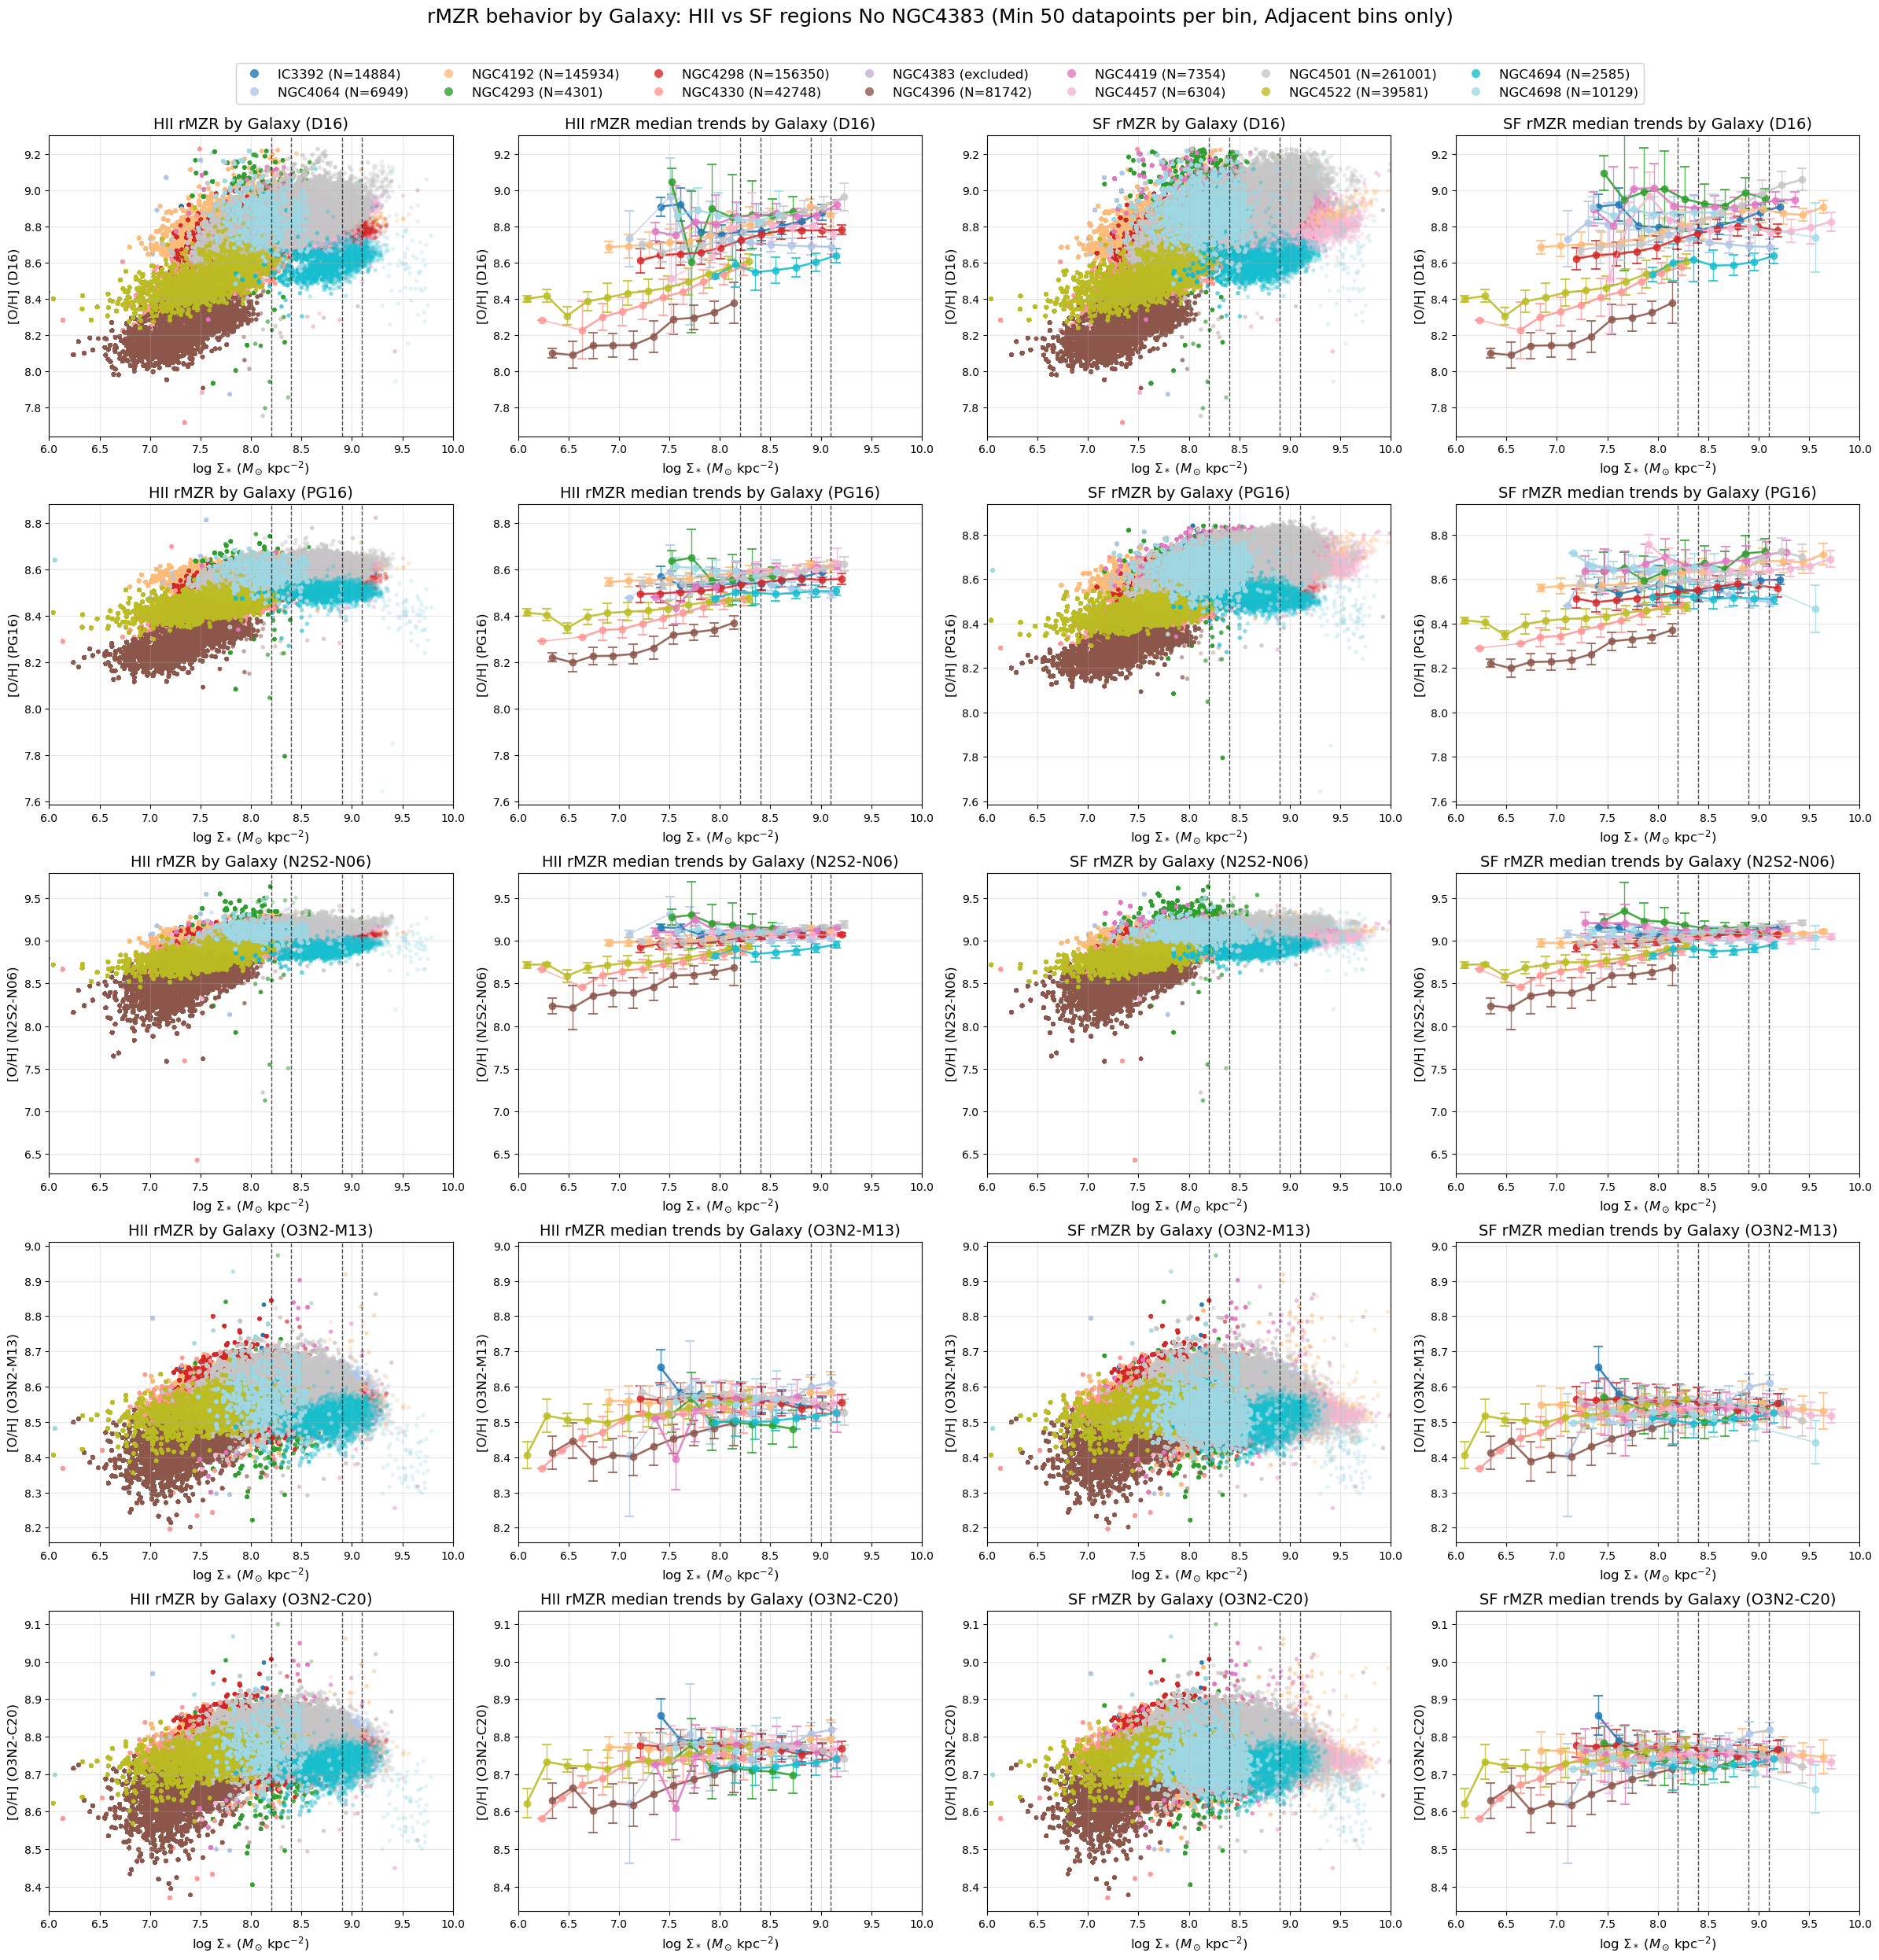


Successfully created combined 5x4 subplot figure showing both HII and SF regions from 14 galaxies
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4383, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Using adaptive y-axis ranges based on actual data ranges for each calibration


In [2]:
# ------------------------------------------------------------------
# Combined Analysis: rMZR behavior by Galaxy - Combined scatter plots and median trends
# Each galaxy in different color
# 5 rows x 4 columns: HII regions (scatter + median) + SF regions (scatter + median)
# 5 calibrations: D16, PG16, N2S2-N06, O3N2-M13, O3N2-C20
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats

def load_maps_all_calibrations(gal):
    """Load all metallicity calibrations for both HII and SF regions"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        # HII regions
        oh_d16_HII = h['O_H_D16_HII'].data
        oh_pg16_HII = h['O_H_PG16_HII'].data
        oh_n2s2_n06_HII = h['O_H_N2S2_N06_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
        oh_o3n2_c20_HII = h['O_H_O3N2_C20_HII'].data
        # SF regions
        oh_d16_SF = h['O_H_D16_SF'].data
        oh_pg16_SF = h['O_H_PG16_SF'].data
        oh_n2s2_n06_SF = h['O_H_N2S2_N06_SF'].data
        oh_o3n2_m13_SF = h['O_H_O3N2_M13_SF'].data
        oh_o3n2_c20_SF = h['O_H_O3N2_C20_SF'].data
    return (sigM, oh_d16_HII, oh_pg16_HII, oh_n2s2_n06_HII, oh_o3n2_m13_HII, oh_o3n2_c20_HII,
            oh_d16_SF, oh_pg16_SF, oh_n2s2_n06_SF, oh_o3n2_m13_SF, oh_o3n2_c20_SF)

def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=50):
    """Calculate median and std in stellar mass bins - only keep bins with >= 50 unique datapoints"""
    # Define mass bins
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    mass_bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    mass_bin_centers = (mass_bin_edges[:-1] + mass_bin_edges[1:]) / 2
    
    medians = []
    stds = []
    counts = []
    valid_centers = []
    valid_bin_indices = []
    
    for i, (bin_start, bin_end) in enumerate(zip(mass_bin_edges[:-1], mass_bin_edges[1:])):
        # Select data in this mass bin
        in_mass_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_mass_bin]
        
        if len(y_in_bin) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(mass_bin_centers[i])
            valid_bin_indices.append(i)
    
    return (np.array(valid_centers), np.array(medians), np.array(stds), 
            np.array(counts), np.array(valid_bin_indices))

def plot_median_trend_with_adjacency(ax, mass_centers, medians, stds, valid_bin_indices, color, label, bin_width=0.2):
    """Plot median trend with lines only connecting adjacent bins"""
    if len(mass_centers) == 0:
        return
    
    # Plot all points with error bars
    ax.errorbar(mass_centers, medians, yerr=stds, 
               color=color, marker='o', markersize=6, 
               linewidth=1, capsize=4, capthick=1.5,  
               label=label, alpha=0.8)
    
    # Now add lines only between adjacent bins
    for i in range(len(valid_bin_indices) - 1):
        current_bin_idx = valid_bin_indices[i]
        next_bin_idx = valid_bin_indices[i + 1]
        
        # Check if bins are adjacent (difference of 1 in bin index)
        if next_bin_idx - current_bin_idx == 1:
            # Draw line between adjacent points
            ax.plot([mass_centers[i], mass_centers[i + 1]], 
                   [medians[i], medians[i + 1]], 
                   color=color, linewidth=2, alpha=0.7)

# Get all galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

print(f"Found {len(galaxies)} galaxies: {', '.join(galaxies)}")

# Create galaxy color mapping (consistent for both HII and SF regions)
galaxy_colors = plt.cm.tab20(np.linspace(0, 1, len(galaxies)))
galaxy_color_dict = dict(zip(galaxies, galaxy_colors))

# Define galaxies to exclude from plotting while retaining their color slots
excluded_galaxies = {'NGC4383'}
if excluded_galaxies:
    print(f"Excluding {', '.join(sorted(excluded_galaxies))} from plotting (colors retained)")

# Define vertical line positions
vline_positions = [8.2, 8.4, 8.9, 9.1]

# Create figure with 5 rows x 4 columns 
# Columns: HII scatter, HII median, SF scatter, SF median
fig, axes = plt.subplots(5, 4, figsize=(24, 25))

# Calibration information
calibration_keys = ['d16', 'pg16', 'n2s2_n06', 'o3n2_m13', 'o3n2_c20']
calibration_names = ['D16', 'PG16', 'N2S2-N06', 'O3N2-M13', 'O3N2-C20']

# Create legend handles (will be populated during first row)
legend_handles = []
legend_labels = []
first_row_hii_counts = {}

# Process each calibration (one row per calibration)
for row_idx, (calib_key, calib_name) in enumerate(zip(calibration_keys, calibration_names)):
    print(f"\nProcessing {calib_name} calibration for both HII and SF regions:")
    
    # Get axes for this row
    ax_scatter_HII = axes[row_idx, 0]  # Column 0: HII scatter plots
    ax_median_HII = axes[row_idx, 1]   # Column 1: HII median trends
    ax_scatter_SF = axes[row_idx, 2]   # Column 2: SF scatter plots
    ax_median_SF = axes[row_idx, 3]    # Column 3: SF median trends
    
    # Collect all data for dynamic y-axis ranges
    all_y_HII = []
    all_y_SF = []
    
    # Plot each galaxy
    for gal_idx, gal in enumerate(galaxies):
        bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
        gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')
        
        if gal in excluded_galaxies:
            if row_idx == 0:
                first_row_hii_counts[gal] = None
                print(f"  {gal}: excluded from plotting (color retained)")
            continue
        
        if not bin_file.exists() or not gas_file.exists():
            if row_idx == 0:
                first_row_hii_counts[gal] = 0
            print(f"  {gal}: Data files not found")
            continue
        
        # Load all data
        (logSigmaM, oh_d16_HII, oh_pg16_HII, oh_n2s2_n06_HII, oh_o3n2_m13_HII, oh_o3n2_c20_HII,
         oh_d16_SF, oh_pg16_SF, oh_n2s2_n06_SF, oh_o3n2_m13_SF, oh_o3n2_c20_SF) = load_maps_all_calibrations(gal)
        
        # Select the calibration for this row
        oh_calib_map_HII = {
            'd16': oh_d16_HII, 'pg16': oh_pg16_HII, 'n2s2_n06': oh_n2s2_n06_HII,
            'o3n2_m13': oh_o3n2_m13_HII, 'o3n2_c20': oh_o3n2_c20_HII
        }
        oh_calib_map_SF = {
            'd16': oh_d16_SF, 'pg16': oh_pg16_SF, 'n2s2_n06': oh_n2s2_n06_SF,
            'o3n2_m13': oh_o3n2_m13_SF, 'o3n2_c20': oh_o3n2_c20_SF
        }
        
        oh_data_HII = oh_calib_map_HII[calib_key]
        oh_data_SF = oh_calib_map_SF[calib_key]
        
        # Find common spaxels for HII regions
        common_mask_HII = np.isfinite(logSigmaM) & np.isfinite(oh_data_HII)
        n_pixels_HII = np.sum(common_mask_HII)
        
        # Find common spaxels for SF regions
        common_mask_SF = np.isfinite(logSigmaM) & np.isfinite(oh_data_SF)
        n_pixels_SF = np.sum(common_mask_SF)
        
        if row_idx == 0:
            first_row_hii_counts[gal] = int(n_pixels_HII)
        
        if n_pixels_HII < 10 and n_pixels_SF < 10:
            print(f"  {gal}: Not enough pixels (HII={n_pixels_HII}, SF={n_pixels_SF})")
            continue
        
        print(f"  {gal}: HII={n_pixels_HII}, SF={n_pixels_SF} pixels")
        
        # Get galaxy color
        color = galaxy_color_dict[gal]
        
        # === HII regions processing ===
        if n_pixels_HII >= 10:
            x_HII = logSigmaM[common_mask_HII]
            y_HII = oh_data_HII[common_mask_HII]
            
            # Collect for y-axis range
            all_y_HII.extend(y_HII.flatten())
            
            # HII Scatter plot (column 0) - don't add label
            ax_scatter_HII.scatter(x_HII, y_HII, c=[color], s=15, alpha=0.3, 
                                 edgecolors='none', rasterized=True)
            
            # HII Median trends (column 1)
            mass_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
                x_HII, y_HII, bin_width=0.2, min_pixels=50)
            
            if len(mass_centers_HII) > 0:
                ax_median_HII.errorbar(mass_centers_HII, medians_HII, yerr=stds_HII, 
                           color=color, marker='o', markersize=6, 
                           linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
                
                # Add lines between adjacent bins
                for i in range(len(valid_bin_indices_HII) - 1):
                    current_bin_idx = valid_bin_indices_HII[i]
                    next_bin_idx = valid_bin_indices_HII[i + 1]
                    if next_bin_idx - current_bin_idx == 1:
                        ax_median_HII.plot([mass_centers_HII[i], mass_centers_HII[i + 1]], 
                               [medians_HII[i], medians_HII[i + 1]], 
                               color=color, linewidth=2, alpha=0.7)
        
        # === SF regions processing ===
        if n_pixels_SF >= 10:
            x_SF = logSigmaM[common_mask_SF]
            y_SF = oh_data_SF[common_mask_SF]
            
            # Collect for y-axis range
            all_y_SF.extend(y_SF.flatten())
            
            # SF Scatter plot (column 2) - don't add label
            ax_scatter_SF.scatter(x_SF, y_SF, c=[color], s=15, alpha=0.3, 
                                edgecolors='none', rasterized=True)
            
            # SF Median trends (column 3) - don't add label
            mass_centers_SF, medians_SF, stds_SF, counts_SF, valid_bin_indices_SF = calculate_binned_stats(
                x_SF, y_SF, bin_width=0.2, min_pixels=50)
            
            if len(mass_centers_SF) > 0:
                ax_median_SF.errorbar(mass_centers_SF, medians_SF, yerr=stds_SF, 
                           color=color, marker='o', markersize=6, 
                           linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
                
                # Add lines between adjacent bins
                for i in range(len(valid_bin_indices_SF) - 1):
                    current_bin_idx = valid_bin_indices_SF[i]
                    next_bin_idx = valid_bin_indices_SF[i + 1]
                    if next_bin_idx - current_bin_idx == 1:
                        ax_median_SF.plot([mass_centers_SF[i], mass_centers_SF[i + 1]], 
                               [medians_SF[i], medians_SF[i + 1]], 
                               color=color, linewidth=2, alpha=0.7)
    
    if row_idx == 0 and not legend_handles:
        for gal_idx, gal in enumerate(galaxies):
            handle = Line2D([], [], marker='o', linestyle='', markersize=8,
                            markerfacecolor=galaxy_colors[gal_idx], markeredgecolor='none', alpha=0.8)
            legend_handles.append(handle)
            if gal in excluded_galaxies:
                legend_labels.append(f'{gal} (excluded)')
            else:
                count = first_row_hii_counts.get(gal, 0)
                legend_labels.append(f'{gal} (N={count})')
    
    # Calculate dynamic y-axis ranges for HII regions
    if all_y_HII:
        y_min_HII = np.min(all_y_HII)
        y_max_HII = np.max(all_y_HII)
        y_range_HII = y_max_HII - y_min_HII
        y_margin_HII = y_range_HII * 0.05  # 5% margin
        ylim_HII = (y_min_HII - y_margin_HII, y_max_HII + y_margin_HII)
    else:
        ylim_HII = (8.0, 9.3)  # fallback
    
    # Calculate dynamic y-axis ranges for SF regions
    if all_y_SF:
        y_min_SF = np.min(all_y_SF)
        y_max_SF = np.max(all_y_SF)
        y_range_SF = y_max_SF - y_min_SF
        y_margin_SF = y_range_SF * 0.05  # 5% margin
        ylim_SF = (y_min_SF - y_margin_SF, y_max_SF + y_margin_SF)
    else:
        ylim_SF = (8.0, 9.3)  # fallback
    
    print(f"  HII y-axis range: {ylim_HII[0]:.3f} to {ylim_HII[1]:.3f}")
    print(f"  SF y-axis range: {ylim_SF[0]:.3f} to {ylim_SF[1]:.3f}")
    
    # Add vertical dashed lines to all four plots in this row
    for vline_x in vline_positions:
        ax_scatter_HII.axvline(x=vline_x, color='black', linestyle='--', alpha=0.7, linewidth=1)
        ax_median_HII.axvline(x=vline_x, color='black', linestyle='--', alpha=0.7, linewidth=1)
        ax_scatter_SF.axvline(x=vline_x, color='black', linestyle='--', alpha=0.7, linewidth=1)
        ax_median_SF.axvline(x=vline_x, color='black', linestyle='--', alpha=0.7, linewidth=1)
    
    # Format HII scatter plot (column 0)
    ax_scatter_HII.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
    ax_scatter_HII.set_ylabel(f'[O/H] ({calib_name})', fontsize=12)
    ax_scatter_HII.set_title(f'HII rMZR by Galaxy ({calib_name})', fontsize=14)
    ax_scatter_HII.grid(True, alpha=0.3)
    ax_scatter_HII.set_xlim(6, 10)
    ax_scatter_HII.set_ylim(ylim_HII)
    
    # Format HII median trends plot (column 1) - use same y-axis as scatter
    ax_median_HII.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
    ax_median_HII.set_ylabel(f'[O/H] ({calib_name})', fontsize=12)
    ax_median_HII.set_title(f'HII rMZR median trends by Galaxy ({calib_name})', fontsize=14)
    ax_median_HII.grid(True, alpha=0.3)
    ax_median_HII.set_xlim(6, 10)
    ax_median_HII.set_ylim(ylim_HII)  # Same as scatter plot
    
    # Format SF scatter plot (column 2)
    ax_scatter_SF.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
    ax_scatter_SF.set_ylabel(f'[O/H] ({calib_name})', fontsize=12)
    ax_scatter_SF.set_title(f'SF rMZR by Galaxy ({calib_name})', fontsize=14)
    ax_scatter_SF.grid(True, alpha=0.3)
    ax_scatter_SF.set_xlim(6, 10)
    ax_scatter_SF.set_ylim(ylim_SF)
    
    # Format SF median trends plot (column 3) - use same y-axis as scatter
    ax_median_SF.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
    ax_median_SF.set_ylabel(f'[O/H] ({calib_name})', fontsize=12)
    ax_median_SF.set_title(f'SF rMZR median trends by Galaxy ({calib_name})', fontsize=14)
    ax_median_SF.grid(True, alpha=0.3)
    ax_median_SF.set_xlim(6, 10)
    ax_median_SF.set_ylim(ylim_SF)  # Same as scatter plot

# Add overall title and adjust layout
fig.suptitle(f'rMZR behavior by Galaxy: HII vs SF regions No NGC4383 (Min 50 datapoints per bin, Adjacent bins only)', 
             fontsize=18, y=0.995)

# Add shared legend below suptitle
fig.legend(legend_handles, legend_labels, loc='upper center', bbox_to_anchor=(0.5, 0.97),
          ncol=min(len(legend_labels), 7), fontsize=12, framealpha=0.9)

plt.tight_layout()
plt.subplots_adjust(top=0.93)  # Make room for suptitle and legend
# plt.savefig('Combined_rMZR_HII_vs_SF_5calibrations_by_galaxy_5x4grid.png', dpi=300, bbox_inches='tight')
# plt.savefig('Combined_rMZR_HII_vs_SF_5calibrations_by_galaxy_5x4grid.pdf', bbox_inches='tight')
plt.show()

print(f"\nSuccessfully created combined 5x4 subplot figure showing both HII and SF regions from {len(galaxies)} galaxies")
print(f"Galaxies included: {', '.join(galaxies)}")
print(f"Using adaptive y-axis ranges based on actual data ranges for each calibration")

  IC3392: 14884 HII pixels, 19776 SF pixels
  IC3392: 14884 HII pixels, 19776 SF pixels
  NGC4064: 6820 HII pixels, 15383 SF pixels
  NGC4064: 6820 HII pixels, 15383 SF pixels
  NGC4192: 145934 HII pixels, 275015 SF pixels
  NGC4192: 145934 HII pixels, 275015 SF pixels
  NGC4293: 3854 HII pixels, 8590 SF pixels
  NGC4293: 3854 HII pixels, 8590 SF pixels
  NGC4298: 156350 HII pixels, 181696 SF pixels
  NGC4298: 156350 HII pixels, 181696 SF pixels
  NGC4330: 42566 HII pixels, 43709 SF pixels
  NGC4383: excluded from SFR-binned analysis
  NGC4330: 42566 HII pixels, 43709 SF pixels
  NGC4383: excluded from SFR-binned analysis
  NGC4396: 81728 HII pixels, 81734 SF pixels
  NGC4396: 81728 HII pixels, 81734 SF pixels
  NGC4419: 6886 HII pixels, 22002 SF pixels
  NGC4419: 6886 HII pixels, 22002 SF pixels
  NGC4457: 6000 HII pixels, 24136 SF pixels
  NGC4457: 6000 HII pixels, 24136 SF pixels
  NGC4501: 260854 HII pixels, 419043 SF pixels
  NGC4501: 260854 HII pixels, 419043 SF pixels
  NGC4522:

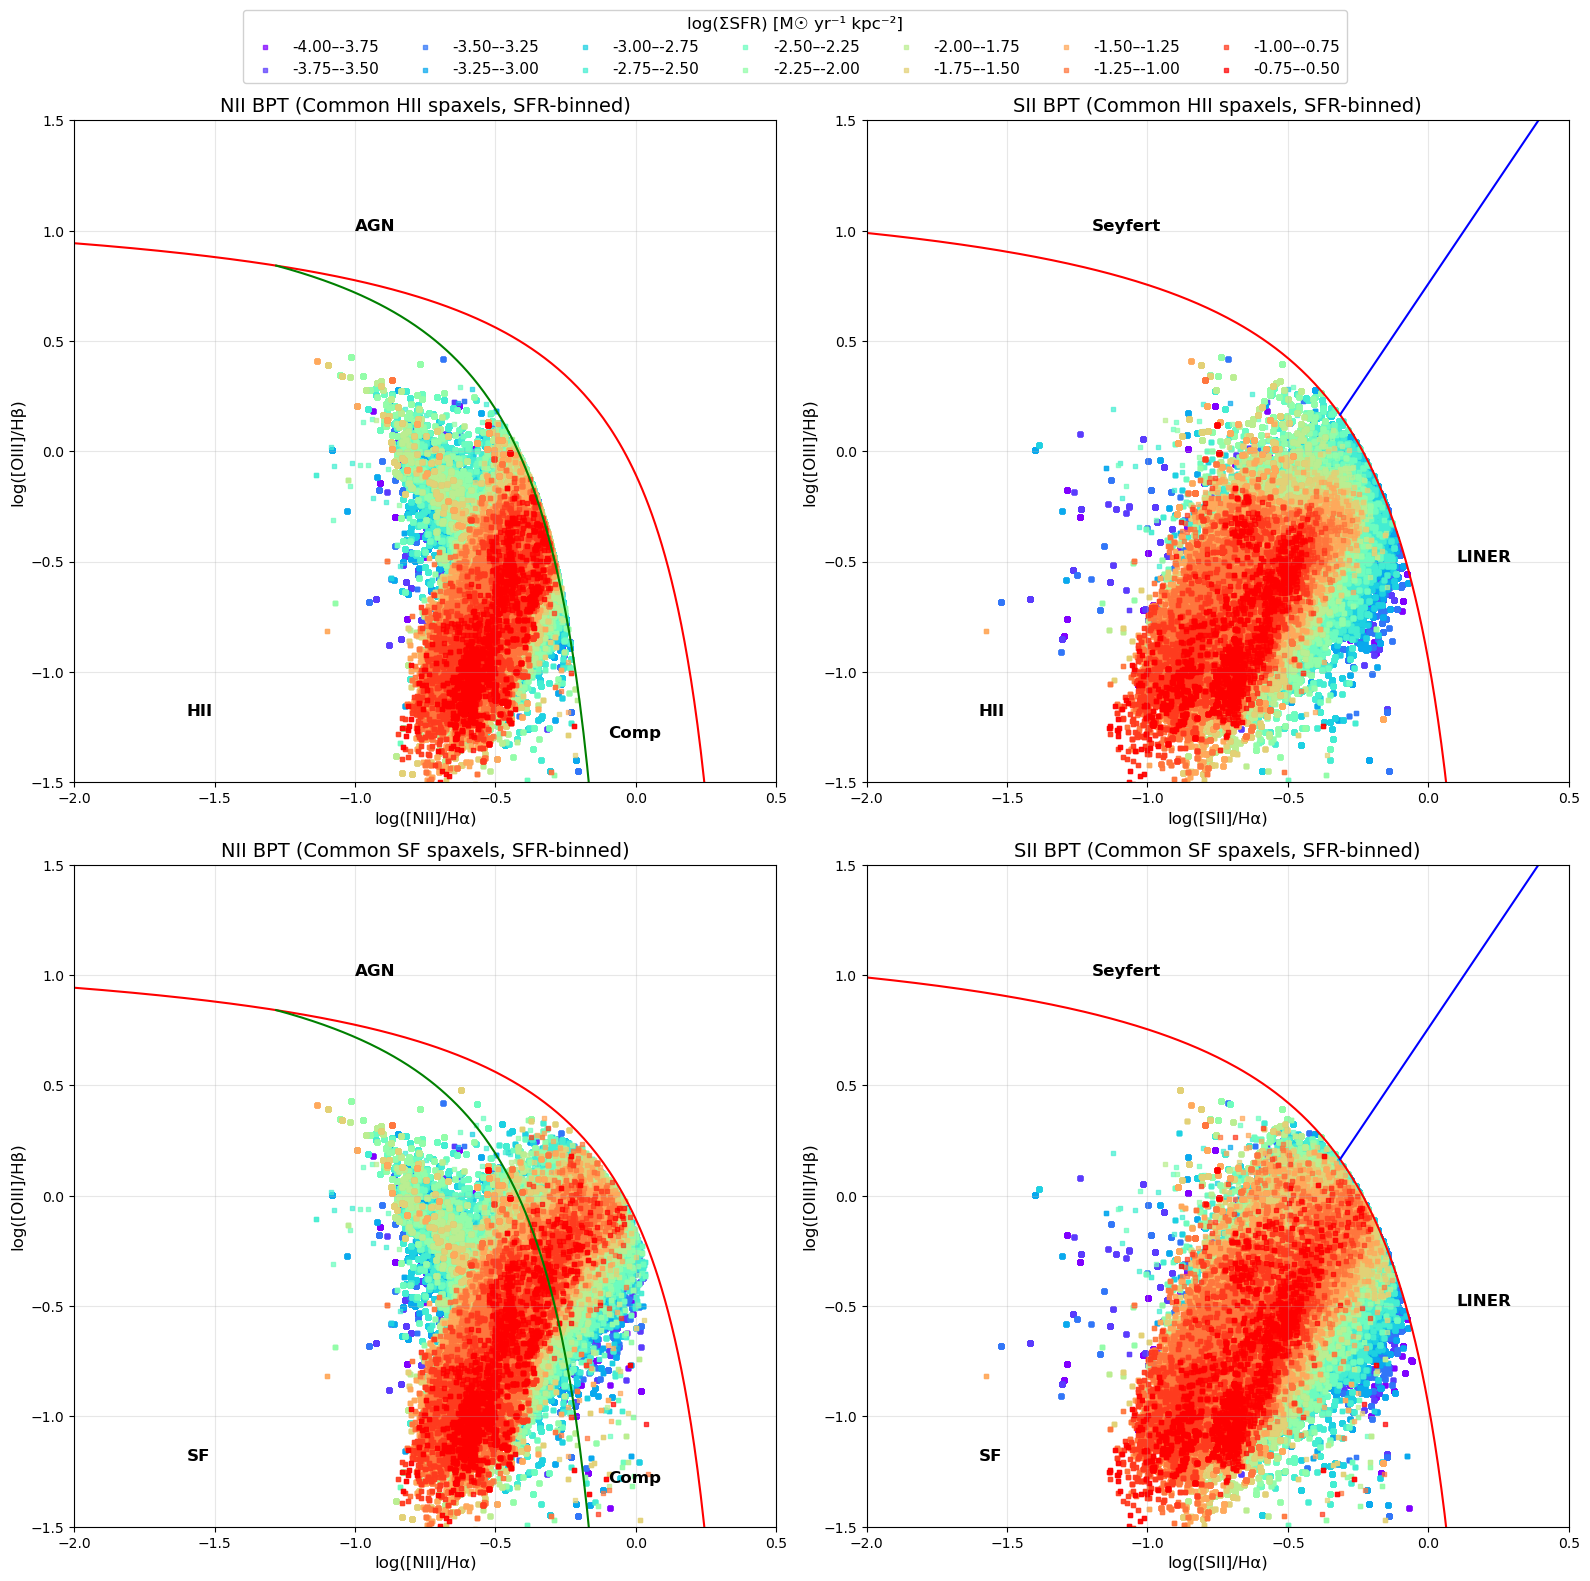


=== Combined BPT Diagram Summary ===

HII Regions:
  N2 BPT - Total HII: 777857 (100.0%)
  S2 BPT - Total HII: 777857 (100.0%)

SF Regions:
  N2 BPT - Total SF: 1169800 (100.0%)
  S2 BPT - Total SF: 1169800 (100.0%)

SFR bin breakdown for HII spaxels:
  Bin 0 (-4.00 to -3.75): N2_HII=4062, S2_HII=4062
  Bin 1 (-3.75 to -3.50): N2_HII=12818, S2_HII=12818
  Bin 2 (-3.50 to -3.25): N2_HII=30193, S2_HII=30193
  Bin 3 (-3.25 to -3.00): N2_HII=55877, S2_HII=55877
  Bin 4 (-3.00 to -2.75): N2_HII=83676, S2_HII=83676
  Bin 5 (-2.75 to -2.50): N2_HII=115475, S2_HII=115475
  Bin 6 (-2.50 to -2.25): N2_HII=129368, S2_HII=129368
  Bin 7 (-2.25 to -2.00): N2_HII=120228, S2_HII=120228
  Bin 8 (-2.00 to -1.75): N2_HII=100054, S2_HII=100054
  Bin 9 (-1.75 to -1.50): N2_HII=65736, S2_HII=65736
  Bin 10 (-1.50 to -1.25): N2_HII=35424, S2_HII=35424
  Bin 11 (-1.25 to -1.00): N2_HII=15078, S2_HII=15078
  Bin 12 (-1.00 to -0.75): N2_HII=4974, S2_HII=4974
  Bin 13 (-0.75 to -0.50): N2_HII=2112, S2_HII=2112

In [3]:
# ------------------------------------------------------------------
# Combined Analysis: NII and SII BPT Diagrams - Color-coded by SFR bins
# Collect all spaxels from all galaxies
# Uses common spaxels across all 4 metallicity calibrations
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits

# BPT reference line functions
def kewley01_N2(x):   # max-starburst
    return 0.61/(x-0.47) + 1.19

def kauff03_N2(x):    # empirical SF upper envelope
    return 0.61/(x-0.05) + 1.30

def kewley01_S2(x):
    return 0.72/(x-0.32) + 1.30

def kewley06_Sy_LIN(x):   # Seyfert/LINER division
    return 1.89*x + 0.76

# Create x arrays for the theoretical lines
x_kewley_N2 = np.linspace(-2.0, 0.3, 200)
x_kauff_N2 = np.linspace((286-np.sqrt(2871561))/1100, 0.0, 200)
x_kewley_S2 = np.linspace(-2.0, 0.3, 200)
x_kewley06_S2 = np.linspace((159-np.sqrt(105081))/525, 0.5, 200)

# Get all galaxies from binning files
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

# Galaxies to exclude entirely (no color retention required)
excluded_galaxies = {'NGC4383'}

# Collect all spaxels from all galaxies - HII
all_logN2_hii = []
all_logO3_hii = []
all_logS2_hii = []
all_logSFR_hii = []

# Collect all spaxels from all galaxies - SF
all_logN2_sf = []
all_logO3_sf = []
all_logS2_sf = []
all_logSFR_sf = []

included_galaxies = []

print("Collecting data from all galaxies...")
for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from SFR-binned analysis")
        continue

    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')
    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')

    if gas_file.exists() and bin_file.exists():
        included_galaxies.append(gal)
        # Load maps for this galaxy
        with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
            logSigmaM = h['LOGMASS_SURFACE_DENSITY'].data
        with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
            # HII
            logSigmaSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
            oh_d16_HII = h['O_H_D16_HII'].data
            oh_pg16_HII = h['O_H_PG16_HII'].data
            oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
            oh_o3n2_c20_HII = h['O_H_O3N2_C20_HII'].data
            
            # SF
            logSigmaSFR_SF = h['LOGSFR_SURFACE_DENSITY_SF'].data
            oh_d16_SF = h['O_H_D16_SF'].data
            oh_pg16_SF = h['O_H_PG16_SF'].data
            oh_o3n2_m13_SF = h['O_H_O3N2_M13_SF'].data
            oh_o3n2_c20_SF = h['O_H_O3N2_C20_SF'].data
            
            # Load corrected emission line fluxes
            HB4861_FLUX_corr = h['HB4861_FLUX_corr'].data
            HA6562_FLUX_corr = h['HA6562_FLUX_corr'].data
            OIII5006_FLUX_corr = h['OIII5006_FLUX_corr'].data
            NII6583_FLUX_corr = h['NII6583_FLUX_corr'].data
            SII6716_FLUX_corr = h['SII6716_FLUX_corr'].data
            SII6730_FLUX_corr = h['SII6730_FLUX_corr'].data
        
        # Find common spaxels for HII
        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                       np.isfinite(oh_d16_HII) & np.isfinite(oh_pg16_HII) & 
                       np.isfinite(oh_o3n2_m13_HII) & np.isfinite(oh_o3n2_c20_HII) &
                       np.isfinite(HB4861_FLUX_corr) & np.isfinite(HA6562_FLUX_corr) &
                       np.isfinite(OIII5006_FLUX_corr) & np.isfinite(NII6583_FLUX_corr) &
                       np.isfinite(SII6716_FLUX_corr) & np.isfinite(SII6730_FLUX_corr))
        
        # Find common spaxels for SF
        common_mask_SF = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_SF) & 
                       np.isfinite(oh_d16_SF) & np.isfinite(oh_pg16_SF) & 
                       np.isfinite(oh_o3n2_m13_SF) & np.isfinite(oh_o3n2_c20_SF) &
                       np.isfinite(HB4861_FLUX_corr) & np.isfinite(HA6562_FLUX_corr) &
                       np.isfinite(OIII5006_FLUX_corr) & np.isfinite(NII6583_FLUX_corr) &
                       np.isfinite(SII6716_FLUX_corr) & np.isfinite(SII6730_FLUX_corr))
        
        print(f"  {gal}: {np.sum(common_mask_HII)} HII pixels, {np.sum(common_mask_SF)} SF pixels")
        
        # Apply common_mask to get valid spaxels - HII
        HB_common_HII = HB4861_FLUX_corr[common_mask_HII]
        HA_common_HII = HA6562_FLUX_corr[common_mask_HII]
        OIII_common_HII = OIII5006_FLUX_corr[common_mask_HII]
        NII_common_HII = NII6583_FLUX_corr[common_mask_HII]
        SII6716_common_HII = SII6716_FLUX_corr[common_mask_HII]
        SII6730_common_HII = SII6730_FLUX_corr[common_mask_HII]
        
        # Apply common_mask to get valid spaxels - SF
        HB_common_SF = HB4861_FLUX_corr[common_mask_SF]
        HA_common_SF = HA6562_FLUX_corr[common_mask_SF]
        OIII_common_SF = OIII5006_FLUX_corr[common_mask_SF]
        NII_common_SF = NII6583_FLUX_corr[common_mask_SF]
        SII6716_common_SF = SII6716_FLUX_corr[common_mask_SF]
        SII6730_common_SF = SII6730_FLUX_corr[common_mask_SF]
        
        # Calculate line ratios - HII
        logN2_hii = np.log10(NII_common_HII / HA_common_HII)
        logO3_hii = np.log10(OIII_common_HII / HB_common_HII)
        logS2_hii = np.log10((SII6716_common_HII + SII6730_common_HII) / HA_common_HII)
        logSFR_hii = logSigmaSFR_HII[common_mask_HII]
        
        # Calculate line ratios - SF
        logN2_sf = np.log10(NII_common_SF / HA_common_SF)
        logO3_sf = np.log10(OIII_common_SF / HB_common_SF)
        logS2_sf = np.log10((SII6716_common_SF + SII6730_common_SF) / HA_common_SF)
        logSFR_sf = logSigmaSFR_SF[common_mask_SF]
        
        # Append to combined arrays - HII
        all_logN2_hii.extend(logN2_hii.flatten())
        all_logO3_hii.extend(logO3_hii.flatten())
        all_logS2_hii.extend(logS2_hii.flatten())
        all_logSFR_hii.extend(logSFR_hii.flatten())
        
        # Append to combined arrays - SF
        all_logN2_sf.extend(logN2_sf.flatten())
        all_logO3_sf.extend(logO3_sf.flatten())
        all_logS2_sf.extend(logS2_sf.flatten())
        all_logSFR_sf.extend(logSFR_sf.flatten())
    else:
        print(f"  {gal}: Data files not found")

# Convert to numpy arrays - HII
all_logN2_hii = np.array(all_logN2_hii)
all_logO3_hii = np.array(all_logO3_hii)
all_logS2_hii = np.array(all_logS2_hii)
all_logSFR_hii = np.array(all_logSFR_hii)

# Convert to numpy arrays - SF
all_logN2_sf = np.array(all_logN2_sf)
all_logO3_sf = np.array(all_logO3_sf)
all_logS2_sf = np.array(all_logS2_sf)
all_logSFR_sf = np.array(all_logSFR_sf)

print(f"\nTotal combined HII pixels: {len(all_logN2_hii)}")
print(f"Total combined SF pixels: {len(all_logN2_sf)}")

# Create SFR bins for color coding (0.25 dex width)
sfr_bin_edges = np.round(np.linspace(-4.0, -0.5, int(((-0.5) - (-4.0)) / 0.25) + 1), 2)
n_bins = len(sfr_bin_edges) - 1

# Assign SFR bin indices - HII
sfr_bin_indices_hii = np.full_like(all_logSFR_hii, -1, dtype=int)

for i in range(n_bins):
    bin_mask = (all_logSFR_hii >= sfr_bin_edges[i]) & (all_logSFR_hii < sfr_bin_edges[i+1])
    if i == n_bins - 1:
        bin_mask = (all_logSFR_hii >= sfr_bin_edges[i]) & (all_logSFR_hii <= sfr_bin_edges[i+1])
    sfr_bin_indices_hii[bin_mask] = i

# Assign SFR bin indices - SF
sfr_bin_indices_sf = np.full_like(all_logSFR_sf, -1, dtype=int)

for i in range(n_bins):
    bin_mask = (all_logSFR_sf >= sfr_bin_edges[i]) & (all_logSFR_sf < sfr_bin_edges[i+1])
    if i == n_bins - 1:
        bin_mask = (all_logSFR_sf >= sfr_bin_edges[i]) & (all_logSFR_sf <= sfr_bin_edges[i+1])
    sfr_bin_indices_sf[bin_mask] = i

# Apply BPT classifications - HII
mask_N2_HII = all_logO3_hii <= kauff03_N2(all_logN2_hii)
mask_N2_Comp = (all_logO3_hii > kauff03_N2(all_logN2_hii)) & (all_logO3_hii <= kewley01_N2(all_logN2_hii))
mask_N2_AGN = all_logO3_hii > kewley01_N2(all_logN2_hii)

mask_S2_HII = all_logO3_hii <= kewley01_S2(all_logS2_hii)
mask_S2_above_kewley = all_logO3_hii > kewley01_S2(all_logS2_hii)
mask_S2_LINER = mask_S2_above_kewley & (all_logO3_hii <= kewley06_Sy_LIN(all_logS2_hii))
mask_S2_Seyfert = mask_S2_above_kewley & (all_logO3_hii > kewley06_Sy_LIN(all_logS2_hii))

mask_HII_N2 = mask_N2_HII | mask_N2_Comp
mask_HII_S2 = mask_S2_HII

# Apply BPT classifications - SF
mask_N2_HII_sf = all_logO3_sf <= kauff03_N2(all_logN2_sf)
mask_N2_Comp_sf = (all_logO3_sf > kauff03_N2(all_logN2_sf)) & (all_logO3_sf <= kewley01_N2(all_logN2_sf))
mask_N2_AGN_sf = all_logO3_sf > kewley01_N2(all_logN2_sf)

mask_S2_HII_sf = all_logO3_sf <= kewley01_S2(all_logS2_sf)
mask_S2_above_kewley_sf = all_logO3_sf > kewley01_S2(all_logS2_sf)
mask_S2_LINER_sf = mask_S2_above_kewley_sf & (all_logO3_sf <= kewley06_Sy_LIN(all_logS2_sf))
mask_S2_Seyfert_sf = mask_S2_above_kewley_sf & (all_logO3_sf > kewley06_Sy_LIN(all_logS2_sf))

mask_HII_N2_sf = mask_N2_HII_sf | mask_N2_Comp_sf
mask_HII_S2_sf = mask_S2_HII_sf

# Create BPT diagrams with 2 rows
fig, axes = plt.subplots(2, 2, figsize=(16, 16))

colors = plt.cm.rainbow(np.linspace(0, 1, n_bins))

# Collect legend handles and labels for shared legend
legend_handles = []
legend_labels = []

# ===== TOP ROW: HII REGIONS =====

# NII BPT Diagram - HII
ax = axes[0, 0]

for i in range(n_bins):
    bin_hii_mask = mask_HII_N2 & (sfr_bin_indices_hii == i)
    if np.sum(bin_hii_mask) > 0:
        scatter = ax.scatter(all_logN2_hii[bin_hii_mask], all_logO3_hii[bin_hii_mask], 
                   color=colors[i], marker=',', s=8, alpha=0.7)
        # Store handles and labels from first subplot only
        if len(legend_handles) < n_bins:
            legend_handles.append(scatter)
            legend_labels.append(f'{sfr_bin_edges[i]:.2f}–{sfr_bin_edges[i+1]:.2f}')

ax.plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'r-', lw=1.5, label='Kewley+01')
ax.plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'g-', lw=1.5, label='Kauffmann+03')

hii_count_N2 = np.sum(mask_HII_N2)
total_common_hii = len(all_logN2_hii)
hii_percent_N2 = hii_count_N2 / total_common_hii * 100 if total_common_hii > 0 else 0

ax.set_xlabel('log([NII]/Hα)', fontsize=12)
ax.set_ylabel('log([OIII]/Hβ)', fontsize=12)
ax.set_xlim(-2.0, 0.5)
ax.set_ylim(-1.5, 1.5)
ax.set_title(f'NII BPT (Common HII spaxels, SFR-binned)', fontsize=14)
ax.text(-1.6, -1.2, 'HII', fontsize=12, fontweight='bold')
ax.text(-0.1, -1.3, 'Comp', fontsize=12, fontweight='bold')
ax.text(-1.0, 1.0, 'AGN', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# SII BPT Diagram - HII
ax = axes[0, 1]

for i in range(n_bins):
    bin_hii_mask = mask_HII_S2 & (sfr_bin_indices_hii == i)
    if np.sum(bin_hii_mask) > 0:
        ax.scatter(all_logS2_hii[bin_hii_mask], all_logO3_hii[bin_hii_mask], 
                   color=colors[i], marker=',', s=8, alpha=0.7)

ax.plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'r-', lw=1.5, label='Kewley+01')
ax.plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'b-', lw=1.5, label='Kewley+06')

hii_count_S2 = np.sum(mask_HII_S2)
hii_percent_S2 = hii_count_S2 / total_common_hii * 100 if total_common_hii > 0 else 0

ax.set_xlabel('log([SII]/Hα)', fontsize=12)
ax.set_ylabel('log([OIII]/Hβ)', fontsize=12)
ax.set_xlim(-2.0, 0.5)
ax.set_ylim(-1.5, 1.5)
ax.set_title(f'SII BPT (Common HII spaxels, SFR-binned)', fontsize=14)
ax.text(-1.6, -1.2, 'HII', fontsize=12, fontweight='bold')
ax.text(-1.2, 1.0, 'Seyfert', fontsize=12, fontweight='bold')
ax.text(0.1, -0.5, 'LINER', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# ===== BOTTOM ROW: SF REGIONS =====

# NII BPT Diagram - SF
ax = axes[1, 0]

for i in range(n_bins):
    bin_sf_mask = mask_HII_N2_sf & (sfr_bin_indices_sf == i)
    if np.sum(bin_sf_mask) > 0:
        ax.scatter(all_logN2_sf[bin_sf_mask], all_logO3_sf[bin_sf_mask], 
                   color=colors[i], marker=',', s=8, alpha=0.7)

ax.plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'r-', lw=1.5, label='Kewley+01')
ax.plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'g-', lw=1.5, label='Kauffmann+03')

sf_count_N2 = np.sum(mask_HII_N2_sf)
total_common_sf = len(all_logN2_sf)
sf_percent_N2 = sf_count_N2 / total_common_sf * 100 if total_common_sf > 0 else 0

ax.set_xlabel('log([NII]/Hα)', fontsize=12)
ax.set_ylabel('log([OIII]/Hβ)', fontsize=12)
ax.set_xlim(-2.0, 0.5)
ax.set_ylim(-1.5, 1.5)
ax.set_title(f'NII BPT (Common SF spaxels, SFR-binned)', fontsize=14)
ax.text(-1.6, -1.2, 'SF', fontsize=12, fontweight='bold')
ax.text(-0.1, -1.3, 'Comp', fontsize=12, fontweight='bold')
ax.text(-1.0, 1.0, 'AGN', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# SII BPT Diagram - SF
ax = axes[1, 1]

for i in range(n_bins):
    bin_sf_mask = mask_HII_S2_sf & (sfr_bin_indices_sf == i)
    if np.sum(bin_sf_mask) > 0:
        ax.scatter(all_logS2_sf[bin_sf_mask], all_logO3_sf[bin_sf_mask], 
                   color=colors[i], marker=',', s=8, alpha=0.7)

ax.plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'r-', lw=1.5, label='Kewley+01')
ax.plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'b-', lw=1.5, label='Kewley+06')

sf_count_S2 = np.sum(mask_HII_S2_sf)
sf_percent_S2 = sf_count_S2 / total_common_sf * 100 if total_common_sf > 0 else 0

ax.set_xlabel('log([SII]/Hα)', fontsize=12)
ax.set_ylabel('log([OIII]/Hβ)', fontsize=12)
ax.set_xlim(-2.0, 0.5)
ax.set_ylim(-1.5, 1.5)
ax.set_title(f'SII BPT (Common SF spaxels, SFR-binned)', fontsize=14)
ax.text(-1.6, -1.2, 'SF', fontsize=12, fontweight='bold')
ax.text(-1.2, 1.0, 'Seyfert', fontsize=12, fontweight='bold')
ax.text(0.1, -0.5, 'LINER', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Add shared legend at the top horizontally
fig.legend(legend_handles, legend_labels, loc='upper center', bbox_to_anchor=(0.5, 0.99),
          ncol=min(len(legend_labels), 7), fontsize=11, framealpha=0.9, 
          title='log(ΣSFR) [M☉ yr⁻¹ kpc⁻²]', title_fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.94])  # Leave space for the legend at the top
# plt.savefig('Combined_BPT_diagrams_SFR_binned_HII_SF.png', dpi=300)
# plt.savefig('Combined_BPT_diagrams_SFR_binned_HII_SF.pdf')
plt.show()

# Print summary statistics
print(f"\n=== Combined BPT Diagram Summary ===")
print(f"\nHII Regions:")
print(f"  N2 BPT - Total HII: {hii_count_N2} ({hii_percent_N2:.1f}%)")
print(f"  S2 BPT - Total HII: {hii_count_S2} ({hii_percent_S2:.1f}%)")

print(f"\nSF Regions:")
print(f"  N2 BPT - Total SF: {sf_count_N2} ({sf_percent_N2:.1f}%)")
print(f"  S2 BPT - Total SF: {sf_count_S2} ({sf_percent_S2:.1f}%)")

# Print SFR bin breakdown
print(f"\nSFR bin breakdown for HII spaxels:")
for i in range(n_bins):
    bin_hii_n2 = np.sum(mask_HII_N2 & (sfr_bin_indices_hii == i))
    bin_hii_s2 = np.sum(mask_HII_S2 & (sfr_bin_indices_hii == i))
    print(f"  Bin {i} ({sfr_bin_edges[i]:.2f} to {sfr_bin_edges[i+1]:.2f}): N2_HII={bin_hii_n2}, S2_HII={bin_hii_s2}")

print(f"\nSFR bin breakdown for SF spaxels:")
for i in range(n_bins):
    bin_sf_n2 = np.sum(mask_HII_N2_sf & (sfr_bin_indices_sf == i))
    bin_sf_s2 = np.sum(mask_HII_S2_sf & (sfr_bin_indices_sf == i))
    print(f"  Bin {i} ({sfr_bin_edges[i]:.2f} to {sfr_bin_edges[i+1]:.2f}): N2_SF={bin_sf_n2}, S2_SF={bin_sf_s2}")

print(f"\nSuccessfully created combined BPT diagrams from {len(included_galaxies)} galaxies")
print(f"Galaxies included: {', '.join(included_galaxies)}")
print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")

  IC3392: HII=14884, SF=19776 pixels
  NGC4064: HII=6820, SF=15383 pixels
  NGC4064: HII=6820, SF=15383 pixels
  NGC4192: HII=145934, SF=275008 pixels
  NGC4192: HII=145934, SF=275008 pixels
  NGC4293: HII=3252, SF=7865 pixels
  NGC4293: HII=3252, SF=7865 pixels
  NGC4298: HII=156350, SF=181696 pixels
  NGC4298: HII=156350, SF=181696 pixels
  NGC4330: HII=42492, SF=43635 pixels
  NGC4383: excluded from Σ_SFR-binned analysis
  NGC4330: HII=42492, SF=43635 pixels
  NGC4383: excluded from Σ_SFR-binned analysis
  NGC4396: HII=81725, SF=81726 pixels
  NGC4419: HII=6839, SF=21955 pixels
  NGC4396: HII=81725, SF=81726 pixels
  NGC4419: HII=6839, SF=21955 pixels
  NGC4457: HII=5938, SF=24074 pixels
  NGC4457: HII=5938, SF=24074 pixels
  NGC4501: HII=260851, SF=419018 pixels
  NGC4501: HII=260851, SF=419018 pixels
  NGC4522: HII=39331, SF=40421 pixels
  NGC4694: HII=2583, SF=3848 pixels
  NGC4698: HII=10040, SF=34411 pixels
  NGC4522: HII=39331, SF=40421 pixels
  NGC4694: HII=2583, SF=3848 pixe

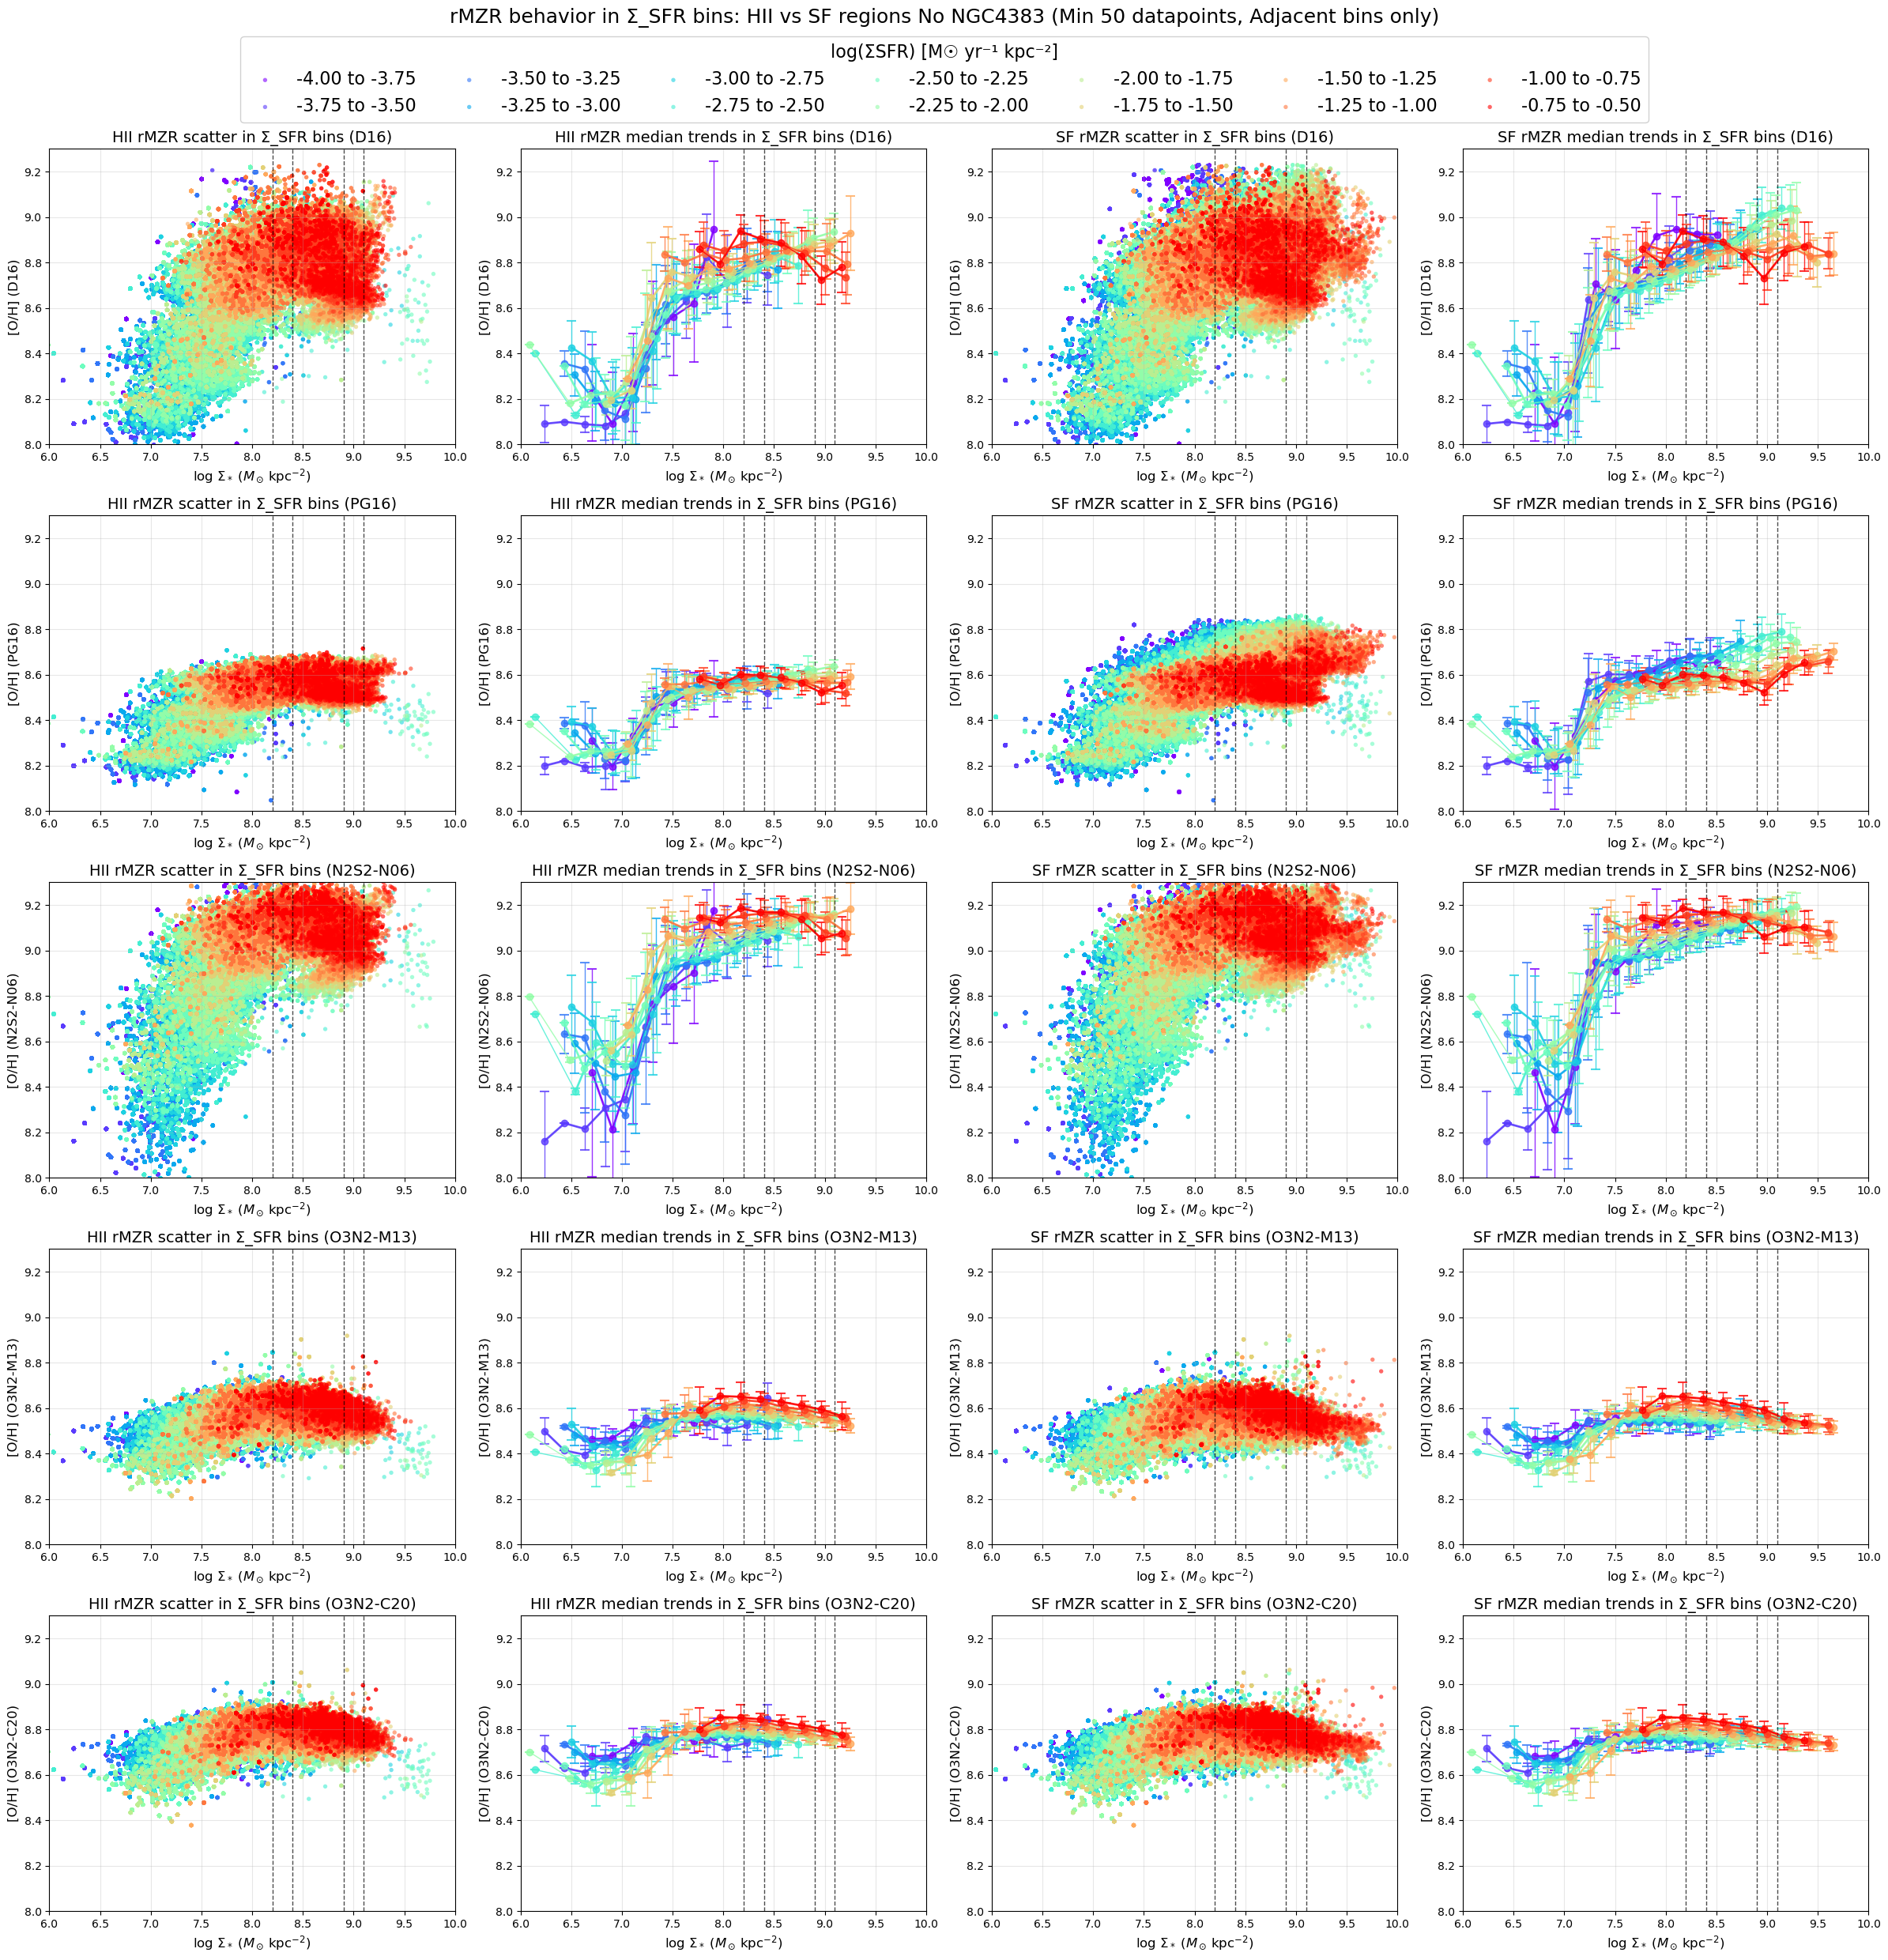


Successfully created combined 5x4 subplot figure showing both HII and SF regions from 13 galaxies
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Excluded: NGC4383


In [4]:
# ------------------------------------------------------------------
# Combined Analysis: rMZR behavior in Σ_SFR bins - Combined scatter plots and median trends
# Collect all spaxels from all galaxies
# 5 rows x 4 columns: HII regions (scatter + median) + SF regions (scatter + median)
# 5 calibrations: D16, PG16, N2S2-N06, O3N2-M13, O3N2-C20
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats

def load_maps_all_calibrations(gal):
    """Load all metallicity calibrations for both HII and SF regions"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        # HII regions
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_d16_HII = h['O_H_D16_HII'].data
        oh_pg16_HII = h['O_H_PG16_HII'].data
        oh_n2s2_n06_HII = h['O_H_N2S2_N06_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
        oh_o3n2_c20_HII = h['O_H_O3N2_C20_HII'].data
        # SF regions
        sigSFR_SF = h['LOGSFR_SURFACE_DENSITY_SF'].data
        oh_d16_SF = h['O_H_D16_SF'].data
        oh_pg16_SF = h['O_H_PG16_SF'].data
        oh_n2s2_n06_SF = h['O_H_N2S2_N06_SF'].data
        oh_o3n2_m13_SF = h['O_H_O3N2_M13_SF'].data
        oh_o3n2_c20_SF = h['O_H_O3N2_C20_SF'].data
    return (sigM, sigSFR_HII, oh_d16_HII, oh_pg16_HII, oh_n2s2_n06_HII, oh_o3n2_m13_HII, oh_o3n2_c20_HII,
            sigSFR_SF, oh_d16_SF, oh_pg16_SF, oh_n2s2_n06_SF, oh_o3n2_m13_SF, oh_o3n2_c20_SF)

def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=50):
    """Calculate median and std in stellar mass bins - only keep bins with >= 50 unique datapoints"""
    # Define mass bins
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    mass_bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    mass_bin_centers = (mass_bin_edges[:-1] + mass_bin_edges[1:]) / 2
    
    medians = []
    stds = []
    counts = []
    valid_centers = []
    valid_bin_indices = []
    
    for i, (bin_start, bin_end) in enumerate(zip(mass_bin_edges[:-1], mass_bin_edges[1:])):
        # Select data in this mass bin
        in_mass_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_mass_bin]
        
        if len(y_in_bin) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(mass_bin_centers[i])
            valid_bin_indices.append(i)
    
    return (np.array(valid_centers), np.array(medians), np.array(stds), 
            np.array(counts), np.array(valid_bin_indices))

# Get all galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

# Galaxies to exclude entirely
excluded_galaxies = {'NGC4383'}
included_galaxies = []

# Collect all spaxels from all galaxies for HII regions
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_d16_HII = []
all_oh_pg16_HII = []
all_oh_n2s2_n06_HII = []
all_oh_o3n2_m13_HII = []
all_oh_o3n2_c20_HII = []

# Collect all spaxels from all galaxies for SF regions
all_logSigmaM_SF = []
all_logSigmaSFR_SF = []
all_oh_d16_SF = []
all_oh_pg16_SF = []
all_oh_n2s2_n06_SF = []
all_oh_o3n2_m13_SF = []
all_oh_o3n2_c20_SF = []

print("Collecting data from all galaxies for HII and SF regions...")
for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from Σ_SFR-binned analysis")
        continue

    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

    if bin_file.exists() and gas_file.exists():
        included_galaxies.append(gal)
        # Load all data for both HII and SF regions
        (logSigmaM, logSigmaSFR_HII, oh_d16_HII, oh_pg16_HII, oh_n2s2_n06_HII, oh_o3n2_m13_HII, oh_o3n2_c20_HII,
         logSigmaSFR_SF, oh_d16_SF, oh_pg16_SF, oh_n2s2_n06_SF, oh_o3n2_m13_SF, oh_o3n2_c20_SF) = load_maps_all_calibrations(gal)

        # Find common spaxels for HII regions
        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                           np.isfinite(oh_d16_HII) & np.isfinite(oh_pg16_HII) & 
                           np.isfinite(oh_n2s2_n06_HII) & np.isfinite(oh_o3n2_m13_HII) & 
                           np.isfinite(oh_o3n2_c20_HII))
        
        # Find common spaxels for SF regions
        common_mask_SF = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_SF) & 
                          np.isfinite(oh_d16_SF) & np.isfinite(oh_pg16_SF) & 
                          np.isfinite(oh_n2s2_n06_SF) & np.isfinite(oh_o3n2_m13_SF) & 
                          np.isfinite(oh_o3n2_c20_SF))
        
        print(f"  {gal}: HII={np.sum(common_mask_HII)}, SF={np.sum(common_mask_SF)} pixels")
        
        # Append HII data
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_d16_HII.extend(oh_d16_HII[common_mask_HII].flatten())
        all_oh_pg16_HII.extend(oh_pg16_HII[common_mask_HII].flatten())
        all_oh_n2s2_n06_HII.extend(oh_n2s2_n06_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
        all_oh_o3n2_c20_HII.extend(oh_o3n2_c20_HII[common_mask_HII].flatten())
        
        # Append SF data
        all_logSigmaM_SF.extend(logSigmaM[common_mask_SF].flatten())
        all_logSigmaSFR_SF.extend(logSigmaSFR_SF[common_mask_SF].flatten())
        all_oh_d16_SF.extend(oh_d16_SF[common_mask_SF].flatten())
        all_oh_pg16_SF.extend(oh_pg16_SF[common_mask_SF].flatten())
        all_oh_n2s2_n06_SF.extend(oh_n2s2_n06_SF[common_mask_SF].flatten())
        all_oh_o3n2_m13_SF.extend(oh_o3n2_m13_SF[common_mask_SF].flatten())
        all_oh_o3n2_c20_SF.extend(oh_o3n2_c20_SF[common_mask_SF].flatten())
    else:
        print(f"  {gal}: Data files not found")

# Convert to numpy arrays
all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_d16_HII = np.array(all_oh_d16_HII)
all_oh_pg16_HII = np.array(all_oh_pg16_HII)
all_oh_n2s2_n06_HII = np.array(all_oh_n2s2_n06_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)
all_oh_o3n2_c20_HII = np.array(all_oh_o3n2_c20_HII)

all_logSigmaM_SF = np.array(all_logSigmaM_SF)
all_logSigmaSFR_SF = np.array(all_logSigmaSFR_SF)
all_oh_d16_SF = np.array(all_oh_d16_SF)
all_oh_pg16_SF = np.array(all_oh_pg16_SF)
all_oh_n2s2_n06_SF = np.array(all_oh_n2s2_n06_SF)
all_oh_o3n2_m13_SF = np.array(all_oh_o3n2_m13_SF)
all_oh_o3n2_c20_SF = np.array(all_oh_o3n2_c20_SF)

print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")
print(f"Total combined pixels (SF): {len(all_logSigmaM_SF)}")

# Define Σ_SFR bins: -4.0 to -0.5 with 0.25 dex bin width
sfr_bin_edges = np.round(np.linspace(-4.0, -0.5, int(((-0.5) - (-4.0)) / 0.25) + 1), 2)
n_bins = len(sfr_bin_edges) - 1

# Colors for different bins
colors = plt.cm.rainbow(np.linspace(0, 1, n_bins))

# Set uniform y-axis range
common_ylim = (8.0, 9.3)

# Define vertical line positions
vline_positions = [8.2, 8.4, 8.9, 9.1]

print(f"Using uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

# Create figure with 5 rows x 4 columns 
# Columns: HII scatter, HII median, SF scatter, SF median
fig, axes = plt.subplots(5, 4, figsize=(24, 25))

# Data for each calibration
calibrations_HII = [
    (all_oh_d16_HII, 'D16'),
    (all_oh_pg16_HII, 'PG16'),
    (all_oh_n2s2_n06_HII, 'N2S2-N06'),
    (all_oh_o3n2_m13_HII, 'O3N2-M13'),
    (all_oh_o3n2_c20_HII, 'O3N2-C20')
]

calibrations_SF = [
    (all_oh_d16_SF, 'D16'),
    (all_oh_pg16_SF, 'PG16'),
    (all_oh_n2s2_n06_SF, 'N2S2-N06'),
    (all_oh_o3n2_m13_SF, 'O3N2-M13'),
    (all_oh_o3n2_c20_SF, 'O3N2-C20')
]

# Create legend handles (will be populated during first row)
legend_handles = []
legend_labels = []

# Process each calibration (one row per calibration)
for row_idx, ((oh_data_HII, calib_name_HII), (oh_data_SF, calib_name_SF)) in enumerate(zip(calibrations_HII, calibrations_SF)):
    print(f"\nProcessing {calib_name_HII} calibration for both HII and SF regions:")
    
    # Get axes for this row
    ax_scatter_HII = axes[row_idx, 0]  # Column 0: HII scatter plots
    ax_median_HII = axes[row_idx, 1]   # Column 1: HII median trends
    ax_scatter_SF = axes[row_idx, 2]   # Column 2: SF scatter plots
    ax_median_SF = axes[row_idx, 3]    # Column 3: SF median trends
    
    print(f"  HII {calib_name_HII} range: {np.min(oh_data_HII):.3f} to {np.max(oh_data_HII):.3f}")
    print(f"  SF {calib_name_SF} range: {np.min(oh_data_SF):.3f} to {np.max(oh_data_SF):.3f}")
    
    # Plot each Σ_SFR bin for both HII and SF regions
    valid_bins_HII = 0
    valid_bins_SF = 0
    
    for i, (bin_start, bin_end) in enumerate(zip(sfr_bin_edges[:-1], sfr_bin_edges[1:])):
        # HII regions processing
        in_bin_HII = (all_logSigmaSFR_HII >= bin_start) & (all_logSigmaSFR_HII < bin_end)
        n_pixels_HII = np.sum(in_bin_HII)
        
        if n_pixels_HII >= 10:  # Process bins with enough pixels
            # Get data for this bin
            x_bin_HII = all_logSigmaM_HII[in_bin_HII]
            y_bin_HII = oh_data_HII[in_bin_HII]
            
            # HII Scatter plot (column 0)
            scatter_hii = ax_scatter_HII.scatter(x_bin_HII, y_bin_HII, c=[colors[i]], s=15, alpha=0.6, 
                                 edgecolors='none', rasterized=True)
            
            # Collect legend info only from first row
            if row_idx == 0 and len(legend_handles) < n_bins:
                legend_handles.append(scatter_hii)
                legend_labels.append(f'{bin_start:.2f} to {bin_end:.2f}')
            
            # HII Median trends (column 1)
            mass_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
                x_bin_HII, y_bin_HII, bin_width=0.2, min_pixels=50)
            
            if len(mass_centers_HII) > 0:
                ax_median_HII.errorbar(mass_centers_HII, medians_HII, yerr=stds_HII, 
                           color=colors[i], marker='o', markersize=6, 
                           linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
                
                # Add lines between adjacent bins
                for j in range(len(valid_bin_indices_HII) - 1):
                    current_bin_idx = valid_bin_indices_HII[j]
                    next_bin_idx = valid_bin_indices_HII[j + 1]
                    if next_bin_idx - current_bin_idx == 1:
                        ax_median_HII.plot([mass_centers_HII[j], mass_centers_HII[j + 1]], 
                               [medians_HII[j], medians_HII[j + 1]], 
                               color=colors[i], linewidth=2, alpha=0.8)
                valid_bins_HII += 1
        
        # SF regions processing
        in_bin_SF = (all_logSigmaSFR_SF >= bin_start) & (all_logSigmaSFR_SF < bin_end)
        n_pixels_SF = np.sum(in_bin_SF)
        
        if n_pixels_SF >= 10:  # Process bins with enough pixels
            # Get data for this bin
            x_bin_SF = all_logSigmaM_SF[in_bin_SF]
            y_bin_SF = oh_data_SF[in_bin_SF]
            
            # SF Scatter plot (column 2)
            ax_scatter_SF.scatter(x_bin_SF, y_bin_SF, c=[colors[i]], s=15, alpha=0.6, 
                                edgecolors='none', rasterized=True)
            
            # SF Median trends (column 3)
            mass_centers_SF, medians_SF, stds_SF, counts_SF, valid_bin_indices_SF = calculate_binned_stats(
                x_bin_SF, y_bin_SF, bin_width=0.2, min_pixels=50)
            
            if len(mass_centers_SF) > 0:
                ax_median_SF.errorbar(mass_centers_SF, medians_SF, yerr=stds_SF, 
                           color=colors[i], marker='o', markersize=6, 
                           linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
                
                # Add lines between adjacent bins
                for j in range(len(valid_bin_indices_SF) - 1):
                    current_bin_idx = valid_bin_indices_SF[j]
                    next_bin_idx = valid_bin_indices_SF[j + 1]
                    if next_bin_idx - current_bin_idx == 1:
                        ax_median_SF.plot([mass_centers_SF[j], mass_centers_SF[j + 1]], 
                               [medians_SF[j], medians_SF[j + 1]], 
                               color=colors[i], linewidth=2, alpha=0.8)
                valid_bins_SF += 1
    
    # Add vertical dashed lines to all four plots in this row
    for vline_x in vline_positions:
        ax_scatter_HII.axvline(x=vline_x, color='black', linestyle='--', alpha=0.7, linewidth=1)
        ax_median_HII.axvline(x=vline_x, color='black', linestyle='--', alpha=0.7, linewidth=1)
        ax_scatter_SF.axvline(x=vline_x, color='black', linestyle='--', alpha=0.7, linewidth=1)
        ax_median_SF.axvline(x=vline_x, color='black', linestyle='--', alpha=0.7, linewidth=1)
    
    # Format HII scatter plot (column 0)
    ax_scatter_HII.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
    ax_scatter_HII.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
    ax_scatter_HII.set_title(f'HII rMZR scatter in Σ_SFR bins ({calib_name_HII})', fontsize=14)
    ax_scatter_HII.grid(True, alpha=0.3)
    ax_scatter_HII.set_xlim(6, 10)
    ax_scatter_HII.set_ylim(common_ylim)
    
    # Format HII median trends plot (column 1)
    ax_median_HII.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
    ax_median_HII.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
    ax_median_HII.set_title(f'HII rMZR median trends in Σ_SFR bins ({calib_name_HII})', fontsize=14)
    ax_median_HII.grid(True, alpha=0.3)
    ax_median_HII.set_xlim(6, 10)
    ax_median_HII.set_ylim(common_ylim)
    
    # Format SF scatter plot (column 2)
    ax_scatter_SF.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
    ax_scatter_SF.set_ylabel(f'[O/H] ({calib_name_SF})', fontsize=12)
    ax_scatter_SF.set_title(f'SF rMZR scatter in Σ_SFR bins ({calib_name_SF})', fontsize=14)
    ax_scatter_SF.grid(True, alpha=0.3)
    ax_scatter_SF.set_xlim(6, 10)
    ax_scatter_SF.set_ylim(common_ylim)
    
    # Format SF median trends plot (column 3)
    ax_median_SF.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
    ax_median_SF.set_ylabel(f'[O/H] ({calib_name_SF})', fontsize=12)
    ax_median_SF.set_title(f'SF rMZR median trends in Σ_SFR bins ({calib_name_SF})', fontsize=14)
    ax_median_SF.grid(True, alpha=0.3)
    ax_median_SF.set_xlim(6, 10)
    ax_median_SF.set_ylim(common_ylim)
    
    print(f"  Total valid bins - HII: {valid_bins_HII}, SF: {valid_bins_SF}")

# Add overall title and adjust layout
fig.suptitle(f'rMZR behavior in Σ_SFR bins: HII vs SF regions No NGC4383 (Min 50 datapoints, Adjacent bins only)', 
             fontsize=18, y=0.99)

# Add shared legend at the top horizontally
fig.legend(legend_handles, legend_labels, loc='upper center', bbox_to_anchor=(0.5, 0.98),
          ncol=min(len(legend_labels), 7), fontsize=16, framealpha=0.9, 
          title='log(ΣSFR) [M☉ yr⁻¹ kpc⁻²]', title_fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for suptitle and legend
# plt.savefig('Combined_rMZR_HII_vs_SF_5calibrations_5x4grid.png', dpi=300, bbox_inches='tight')
# plt.savefig('Combined_rMZR_HII_vs_SF_5calibrations_5x4grid.pdf', bbox_inches='tight')
plt.show()

print(f"\nSuccessfully created combined 5x4 subplot figure showing both HII and SF regions from {len(included_galaxies)} galaxies")
print(f"Galaxies included: {', '.join(included_galaxies)}")
print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")

  IC3392: HII=14884 pixels
  NGC4064: HII=6820 pixels
  IC3392: HII=14884 pixels
  NGC4064: HII=6820 pixels
  NGC4192: HII=145934 pixels
  NGC4293: HII=3854 pixels
  NGC4192: HII=145934 pixels
  NGC4293: HII=3854 pixels
  NGC4298: HII=156350 pixels
  NGC4330: HII=42566 pixels
  NGC4383: excluded from Σ_SFR-binned analysis
  NGC4298: HII=156350 pixels
  NGC4330: HII=42566 pixels
  NGC4383: excluded from Σ_SFR-binned analysis
  NGC4396: HII=81728 pixels
  NGC4419: HII=6886 pixels
  NGC4396: HII=81728 pixels
  NGC4419: HII=6886 pixels
  NGC4457: HII=6000 pixels
  NGC4457: HII=6000 pixels
  NGC4501: HII=260854 pixels
  NGC4522: HII=39354 pixels
  NGC4501: HII=260854 pixels
  NGC4522: HII=39354 pixels
  NGC4694: HII=2585 pixels
  NGC4698: HII=10042 pixels

Total combined pixels (HII): 777857
Using uniform y-axis range: 8.0 to 9.3

Processing D16 calibration for HII regions:
  HII D16 range: 7.906 to 9.229
  NGC4694: HII=2585 pixels
  NGC4698: HII=10042 pixels

Total combined pixels (HII): 7

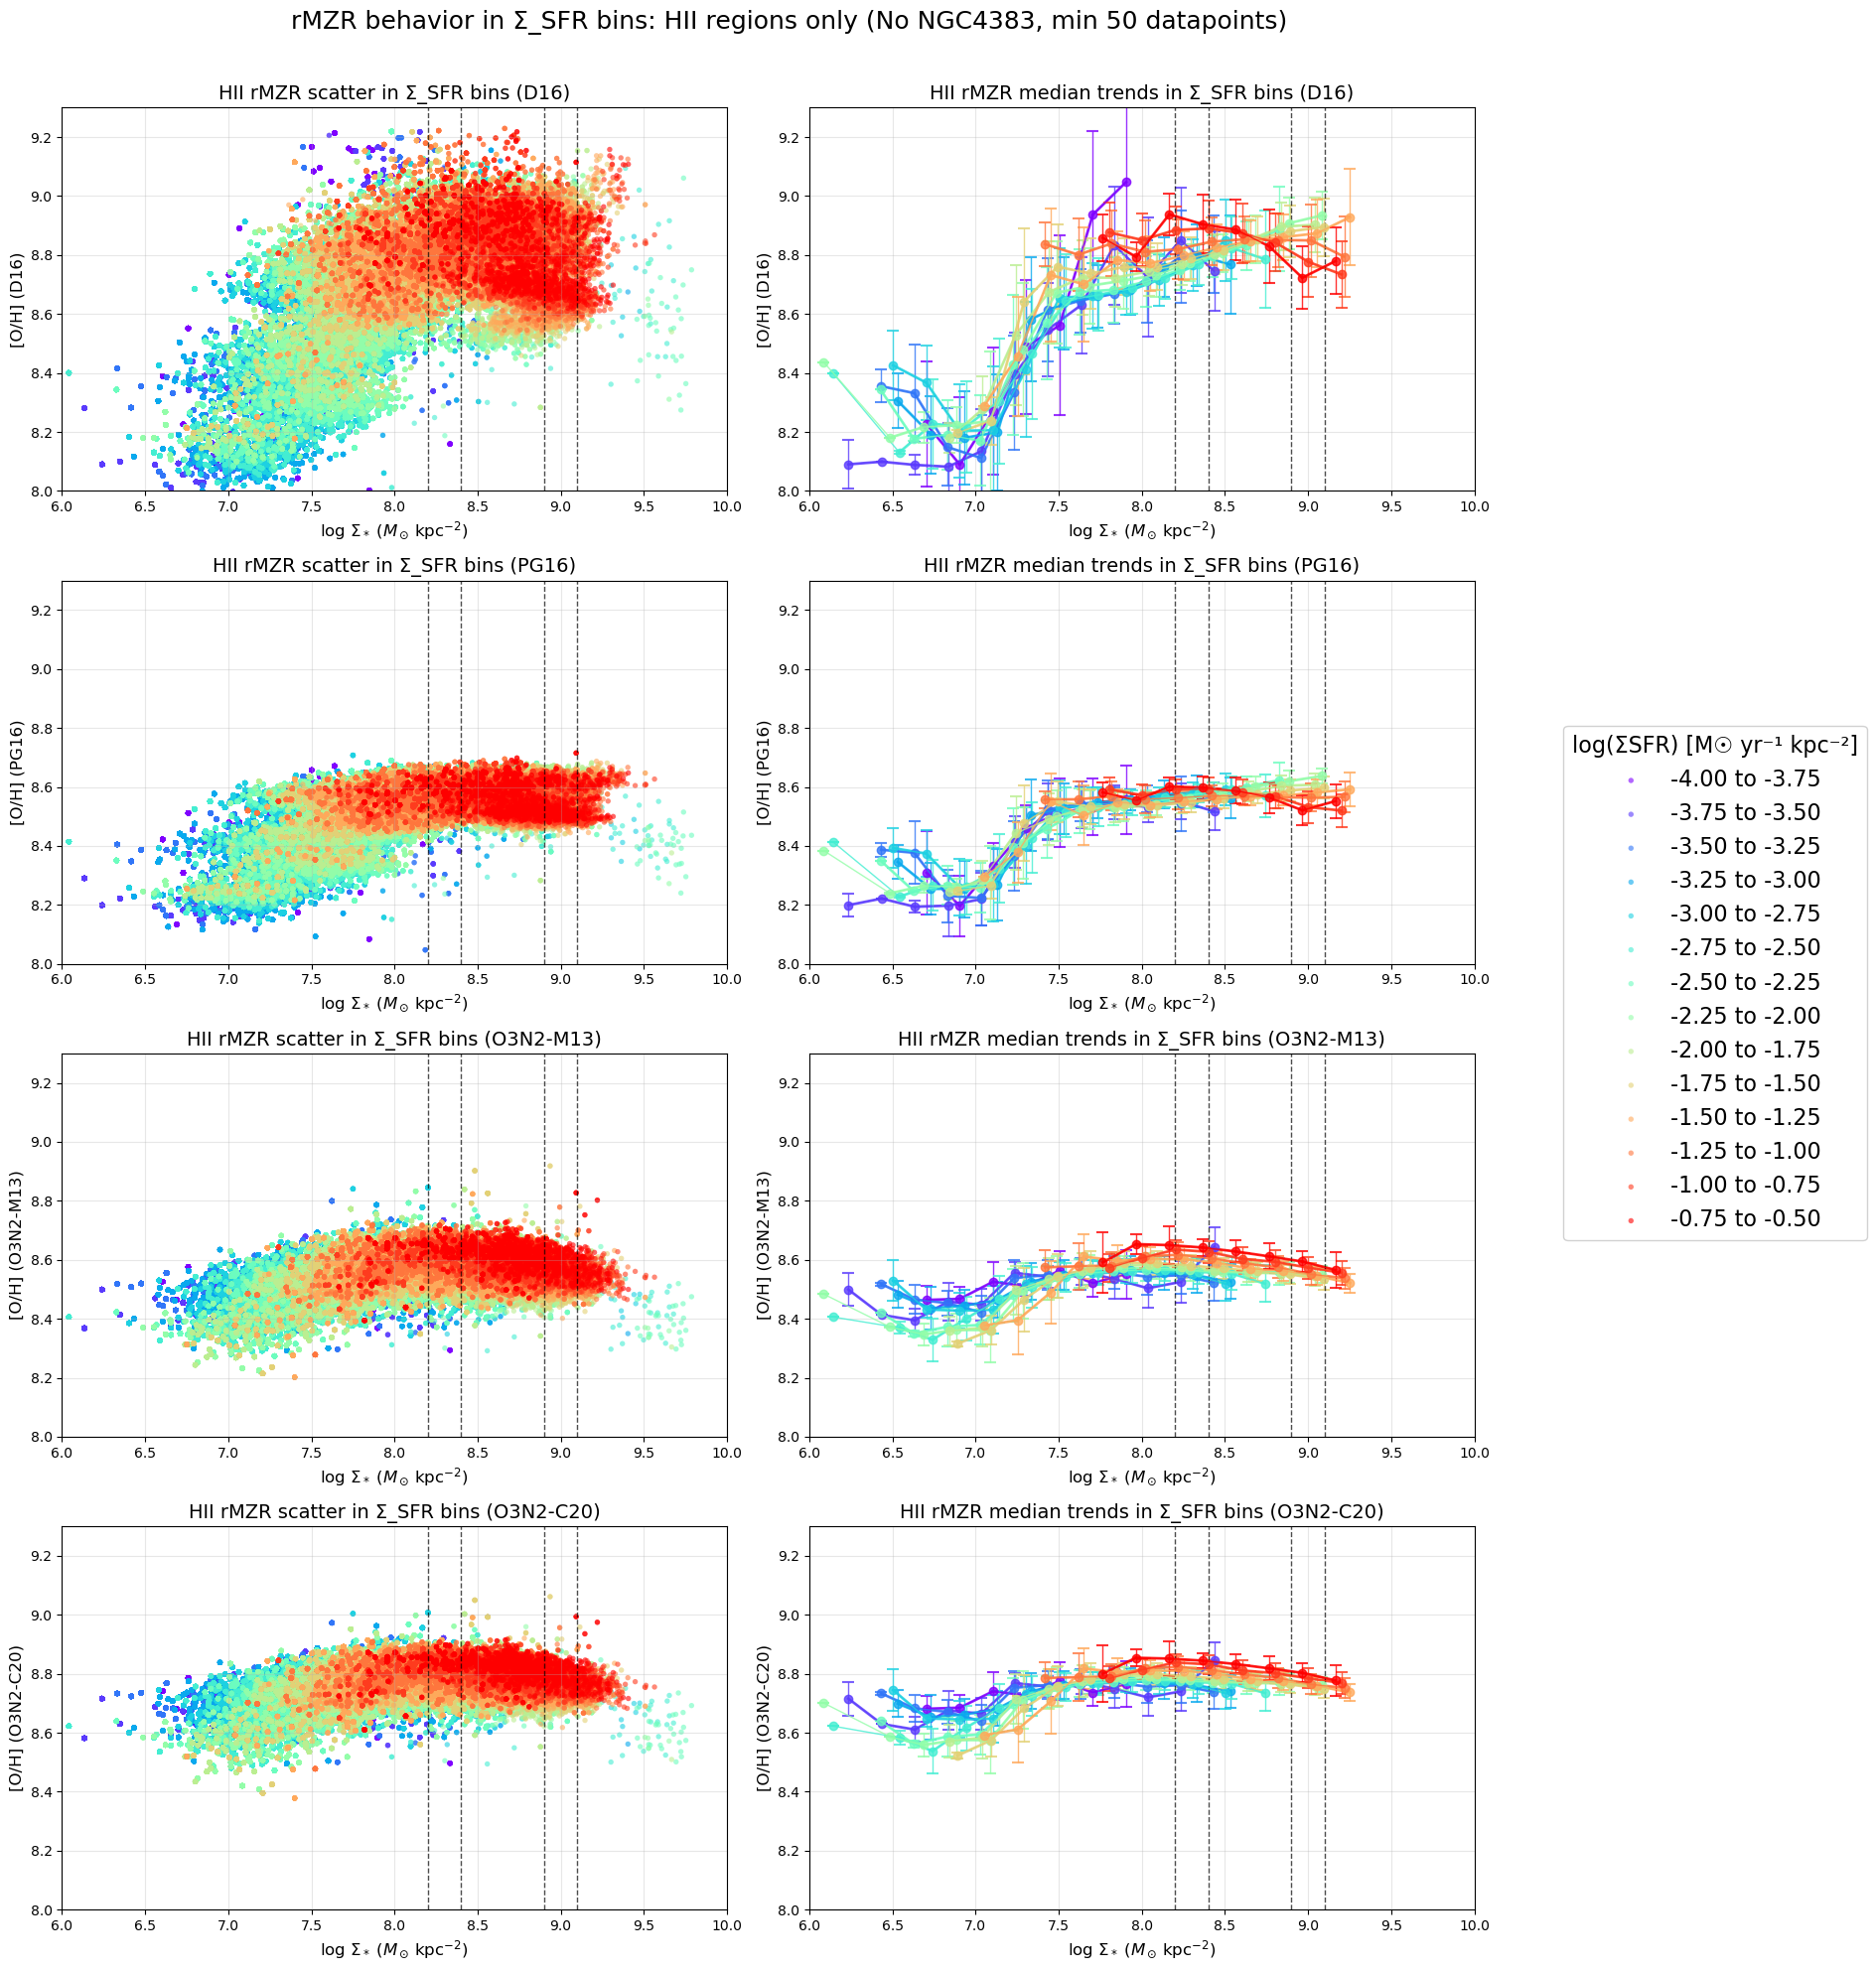


Successfully created combined 4x2 subplot figure showing HII regions from 13 galaxies
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Excluded: NGC4383


In [5]:
# ------------------------------------------------------------------
# Combined Analysis: rMZR behavior in Σ_SFR bins - HII scatter plots and median trends
# Collect all spaxels from all galaxies (HII regions only)
# 4 rows x 2 columns: scatter + median trends for each calibration
# Calibrations: D16, PG16, O3N2-M13, O3N2-C20
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats

def load_maps_all_calibrations(gal):
    """Load the metallicity calibrations for HII regions only."""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_d16_HII = h['O_H_D16_HII'].data
        oh_pg16_HII = h['O_H_PG16_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
        oh_o3n2_c20_HII = h['O_H_O3N2_C20_HII'].data
    return (sigM, sigSFR_HII, oh_d16_HII, oh_pg16_HII, oh_o3n2_m13_HII, oh_o3n2_c20_HII)

def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=50):
    """Calculate median and std in stellar mass bins - only keep bins with >= 50 datapoints."""
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    mass_bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    mass_bin_centers = (mass_bin_edges[:-1] + mass_bin_edges[1:]) / 2

    medians = []
    stds = []
    counts = []
    valid_centers = []
    valid_bin_indices = []

    for i, (bin_start, bin_end) in enumerate(zip(mass_bin_edges[:-1], mass_bin_edges[1:])):
        in_mass_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_mass_bin]

        if len(y_in_bin) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(mass_bin_centers[i])
            valid_bin_indices.append(i)

    return (np.array(valid_centers), np.array(medians), np.array(stds),
            np.array(counts), np.array(valid_bin_indices))

# Get all galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

# Galaxies to exclude entirely
excluded_galaxies = {'NGC4383'}
included_galaxies = []

# Collect all spaxels from all galaxies for HII regions
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_d16_HII = []
all_oh_pg16_HII = []
all_oh_o3n2_m13_HII = []
all_oh_o3n2_c20_HII = []

print("Collecting data from all galaxies for HII regions...")
for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from Σ_SFR-binned analysis")
        continue

    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

    if bin_file.exists() and gas_file.exists():
        included_galaxies.append(gal)
        (logSigmaM, logSigmaSFR_HII,
         oh_d16_HII, oh_pg16_HII,
         oh_o3n2_m13_HII, oh_o3n2_c20_HII) = load_maps_all_calibrations(gal)

        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) &
                           np.isfinite(oh_d16_HII) & np.isfinite(oh_pg16_HII) &
                           np.isfinite(oh_o3n2_m13_HII) & np.isfinite(oh_o3n2_c20_HII))

        print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")

        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_d16_HII.extend(oh_d16_HII[common_mask_HII].flatten())
        all_oh_pg16_HII.extend(oh_pg16_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
        all_oh_o3n2_c20_HII.extend(oh_o3n2_c20_HII[common_mask_HII].flatten())
    else:
        print(f"  {gal}: Data files not found")

# Convert to numpy arrays
all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_d16_HII = np.array(all_oh_d16_HII)
all_oh_pg16_HII = np.array(all_oh_pg16_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)
all_oh_o3n2_c20_HII = np.array(all_oh_o3n2_c20_HII)

print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")

# Define Σ_SFR bins: -4.0 to -0.5 with 0.25 dex bin width
sfr_bin_edges = np.round(np.linspace(-4.0, -0.5, int(((-0.5) - (-4.0)) / 0.25) + 1), 2)
n_bins = len(sfr_bin_edges) - 1

# Colors for different bins
colors = plt.cm.rainbow(np.linspace(0, 1, n_bins))

# Set uniform y-axis range
common_ylim = (8.0, 9.3)

# Define vertical line positions
vline_positions = [8.2, 8.4, 8.9, 9.1]

print(f"Using uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

# Create figure with 4 rows x 2 columns (scatter + median trends)
fig, axes = plt.subplots(4, 2, figsize=(16, 20))

# Data for each calibration (HII only)
calibrations_HII = [
    (all_oh_d16_HII, 'D16'),
    (all_oh_pg16_HII, 'PG16'),
    (all_oh_o3n2_m13_HII, 'O3N2-M13'),
    (all_oh_o3n2_c20_HII, 'O3N2-C20')
]

legend_handles = []
legend_labels = []

# Process each calibration (one row per calibration)
for row_idx, (oh_data_HII, calib_name_HII) in enumerate(calibrations_HII):
    print(f"\nProcessing {calib_name_HII} calibration for HII regions:")

    ax_scatter_HII = axes[row_idx, 0]
    ax_median_HII = axes[row_idx, 1]

    if len(oh_data_HII) > 0:
        print(f"  HII {calib_name_HII} range: {np.nanmin(oh_data_HII):.3f} to {np.nanmax(oh_data_HII):.3f}")
    else:
        print("  HII data array is empty")

    valid_bins_HII = 0

    for i, (bin_start, bin_end) in enumerate(zip(sfr_bin_edges[:-1], sfr_bin_edges[1:])):
        in_bin_HII = (all_logSigmaSFR_HII >= bin_start) & (all_logSigmaSFR_HII < bin_end)
        n_pixels_HII = np.sum(in_bin_HII)

        if n_pixels_HII >= 10:
            x_bin_HII = all_logSigmaM_HII[in_bin_HII]
            y_bin_HII = oh_data_HII[in_bin_HII]

            scatter_hii = ax_scatter_HII.scatter(x_bin_HII, y_bin_HII, c=[colors[i]], s=15, alpha=0.6,
                                 edgecolors='none', rasterized=True)

            if row_idx == 0 and len(legend_handles) < n_bins:
                legend_handles.append(scatter_hii)
                legend_labels.append(f'{bin_start:.2f} to {bin_end:.2f}')

            mass_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
                x_bin_HII, y_bin_HII, bin_width=0.2, min_pixels=50)

            if len(mass_centers_HII) > 0:
                ax_median_HII.errorbar(mass_centers_HII, medians_HII, yerr=stds_HII,
                           color=colors[i], marker='o', markersize=6,
                           linewidth=1, capsize=4, capthick=1.5, alpha=0.8)

                for j in range(len(valid_bin_indices_HII) - 1):
                    current_bin_idx = valid_bin_indices_HII[j]
                    next_bin_idx = valid_bin_indices_HII[j + 1]
                    if next_bin_idx - current_bin_idx == 1:
                        ax_median_HII.plot([mass_centers_HII[j], mass_centers_HII[j + 1]],
                               [medians_HII[j], medians_HII[j + 1]],
                               color=colors[i], linewidth=2, alpha=0.8)
                valid_bins_HII += 1

    for vline_x in vline_positions:
        ax_scatter_HII.axvline(x=vline_x, color='black', linestyle='--', alpha=0.7, linewidth=1)
        ax_median_HII.axvline(x=vline_x, color='black', linestyle='--', alpha=0.7, linewidth=1)

    ax_scatter_HII.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
    ax_scatter_HII.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
    ax_scatter_HII.set_title(f'HII rMZR scatter in Σ_SFR bins ({calib_name_HII})', fontsize=14)
    ax_scatter_HII.grid(True, alpha=0.3)
    ax_scatter_HII.set_xlim(6, 10)
    ax_scatter_HII.set_ylim(common_ylim)

    ax_median_HII.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
    ax_median_HII.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
    ax_median_HII.set_title(f'HII rMZR median trends in Σ_SFR bins ({calib_name_HII})', fontsize=14)
    ax_median_HII.grid(True, alpha=0.3)
    ax_median_HII.set_xlim(6, 10)
    ax_median_HII.set_ylim(common_ylim)

    print(f"  Total valid bins: {valid_bins_HII}")

fig.suptitle('rMZR behavior in Σ_SFR bins: HII regions only (No NGC4383, min 50 datapoints)', fontsize=18, y=0.99)

fig.legend(legend_handles, legend_labels, loc='center left', bbox_to_anchor=(0.98, 0.5),
          ncol=1, fontsize=16, framealpha=0.9,
          title='log(ΣSFR) [M☉ yr⁻¹ kpc⁻²]', title_fontsize=16)

plt.tight_layout(rect=[0, 0, 0.95, 0.98])
# plt.savefig('Combined_rMZR_HII_4calibrations_4x2grid.png', dpi=300, bbox_inches='tight')
# plt.savefig('Combined_rMZR_HII_4calibrations_4x2grid.pdf', bbox_inches='tight')
plt.show()

print(f"\nSuccessfully created combined 4x2 subplot figure showing HII regions from {len(included_galaxies)} galaxies")
print(f"Galaxies included: {', '.join(included_galaxies)}")
print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")